In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from tensorflow.keras.layers import Dense, Flatten, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [4]:
train_path = "Dataset/output/train"
test_path = "Dataset/output/val"

In [5]:
IMAGE_SIZE = [128,128]

In [6]:
# Scaling all the images between 0 to 1

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=False)

# Performing only scaling on the test dataset

test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
train_set = train_datagen.flow_from_directory(train_path,
                                              target_size=(128,128),
                                              batch_size=2,
                                              class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(test_path,
                                            target_size=(128,128),
                                            batch_size=2,
                                            class_mode='categorical')

Found 4479 images belonging to 4 classes.
Found 1921 images belonging to 4 classes.


In [8]:
from keras import backend as K

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+K.epsilon()))

In [9]:
from keras.metrics import Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model

learning_rate_reduction = ReduceLROnPlateau(
    monitor="val_accuracy", patience=3, verbose=1, factor=0.3, min_lr=0.0000001
)
early_stop = EarlyStopping(
    patience=20,
    verbose=1,
    monitor="val_accuracy",
    mode="max",
    min_delta=0.001,
    restore_best_weights=True,
)

In [34]:
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

#function to call for storing the results
def storeResults(model, a,b,c,d):
    ML_Model.append(model)
    accuracy.append(round(a, 3))
    precision.append(round(b, 3))
    recall.append(round(c, 3))
    f1score.append(round(d, 3))

In [11]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import *

In [12]:
from tensorflow.keras.applications import InceptionV3,ResNet50,ResNet152,ResNet101,ResNet101V2,InceptionResNetV2,VGG19,MobileNetV2,DenseNet121,DenseNet169,DenseNet201

# InceptionV3

In [13]:
base_model = InceptionV3(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model1 = Model(inputs = base_model.inputs, outputs = prediction1)
model1.summary()
model1.compile(loss = 'categorical_crossentropy', optimizer='sgd', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 63, 63, 32)   864         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 63, 63, 32)  96          ['conv2d[0][0]']                 
 alization)                                                                                       
                                                                                              

 batch_normalization_10 (BatchN  (None, 13, 13, 96)  288         ['conv2d_10[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_11 (BatchN  (None, 13, 13, 32)  96          ['conv2d_11[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_5 (Activation)      (None, 13, 13, 64)   0           ['batch_normalization_5[0][0]']  
                                                                                                  
 activation_7 (Activation)      (None, 13, 13, 64)   0           ['batch_normalization_7[0][0]']  
                                                                                                  
 activatio

 conv2d_20 (Conv2D)             (None, 13, 13, 48)   13824       ['mixed1[0][0]']                 
                                                                                                  
 conv2d_23 (Conv2D)             (None, 13, 13, 96)   55296       ['activation_22[0][0]']          
                                                                                                  
 batch_normalization_20 (BatchN  (None, 13, 13, 48)  144         ['conv2d_20[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_23 (BatchN  (None, 13, 13, 96)  288         ['conv2d_23[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activatio

                                                                                                  
 conv2d_34 (Conv2D)             (None, 6, 6, 128)    98304       ['mixed3[0][0]']                 
                                                                                                  
 batch_normalization_34 (BatchN  (None, 6, 6, 128)   384         ['conv2d_34[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_34 (Activation)     (None, 6, 6, 128)    0           ['batch_normalization_34[0][0]'] 
                                                                                                  
 conv2d_35 (Conv2D)             (None, 6, 6, 128)    114688      ['activation_34[0][0]']          
                                                                                                  
 batch_nor

                                                                                                  
 activation_44 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_44[0][0]'] 
                                                                                                  
 conv2d_45 (Conv2D)             (None, 6, 6, 160)    179200      ['activation_44[0][0]']          
                                                                                                  
 batch_normalization_45 (BatchN  (None, 6, 6, 160)   480         ['conv2d_45[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_45 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_45[0][0]'] 
                                                                                                  
 conv2d_41

 batch_normalization_55 (BatchN  (None, 6, 6, 160)   480         ['conv2d_55[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_55 (Activation)     (None, 6, 6, 160)    0           ['batch_normalization_55[0][0]'] 
                                                                                                  
 conv2d_51 (Conv2D)             (None, 6, 6, 160)    122880      ['mixed5[0][0]']                 
                                                                                                  
 conv2d_56 (Conv2D)             (None, 6, 6, 160)    179200      ['activation_55[0][0]']          
                                                                                                  
 batch_normalization_51 (BatchN  (None, 6, 6, 160)   480         ['conv2d_51[0][0]']              
 ormalizat

 conv2d_61 (Conv2D)             (None, 6, 6, 192)    147456      ['mixed6[0][0]']                 
                                                                                                  
 conv2d_66 (Conv2D)             (None, 6, 6, 192)    258048      ['activation_65[0][0]']          
                                                                                                  
 batch_normalization_61 (BatchN  (None, 6, 6, 192)   576         ['conv2d_61[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 batch_normalization_66 (BatchN  (None, 6, 6, 192)   576         ['conv2d_66[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activatio

 ormalization)                                                                                    
                                                                                                  
 batch_normalization_74 (BatchN  (None, 6, 6, 192)   576         ['conv2d_74[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_70 (Activation)     (None, 6, 6, 192)    0           ['batch_normalization_70[0][0]'] 
                                                                                                  
 activation_74 (Activation)     (None, 6, 6, 192)    0           ['batch_normalization_74[0][0]'] 
                                                                                                  
 conv2d_71 (Conv2D)             (None, 2, 2, 320)    552960      ['activation_70[0][0]']          
          

                                                                                                  
 activation_82 (Activation)     (None, 2, 2, 384)    0           ['batch_normalization_82[0][0]'] 
                                                                                                  
 activation_83 (Activation)     (None, 2, 2, 384)    0           ['batch_normalization_83[0][0]'] 
                                                                                                  
 batch_normalization_84 (BatchN  (None, 2, 2, 192)   576         ['conv2d_84[0][0]']              
 ormalization)                                                                                    
                                                                                                  
 activation_76 (Activation)     (None, 2, 2, 320)    0           ['batch_normalization_76[0][0]'] 
                                                                                                  
 mixed9_0 

 ormalization)                                                                                    
                                                                                                  
 activation_85 (Activation)     (None, 2, 2, 320)    0           ['batch_normalization_85[0][0]'] 
                                                                                                  
 mixed9_1 (Concatenate)         (None, 2, 2, 768)    0           ['activation_87[0][0]',          
                                                                  'activation_88[0][0]']          
                                                                                                  
 concatenate_1 (Concatenate)    (None, 2, 2, 768)    0           ['activation_91[0][0]',          
                                                                  'activation_92[0][0]']          
                                                                                                  
 activatio

In [14]:
hist1 = model1.fit(
    train_set,
    epochs=100,
    validation_data=test_set,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 122s 50ms/step - loss: 1.7514 - accuracy: 0.4081 - f1_m: 0.3894 - precision_m: 0.4107 - recall_m: 0.3788 - val_loss: 1.3140 - val_accuracy: 0.5242 - val_f1_m: 0.5118 - val_precision_m: 0.5291 - val_recall_m: 0.5031 - lr: 0.0100
Epoch 2/100
2240/2240 [==============================] - 106s 47ms/step - loss: 1.2972 - accuracy: 0.4287 - f1_m: 0.3783 - precision_m: 0.4221 - recall_m: 0.3565 - val_loss: 1.8658 - val_accuracy: 0.4904 - val_f1_m: 0.4792 - val_precision_m: 0.4958 - val_recall_m: 0.4709 - lr: 0.0100
Epoch 3/100
2240/2240 [==============================] - 115s 51ms/step - loss: 1.1528 - accuracy: 0.4586 - f1_m: 0.3884 - precision_m: 0.4638 - recall_m: 0.3507 - val_loss: 1.2474 - val_accuracy: 0.3889 - val_f1_m: 0.0911 - val_precision_m: 0.1285 - val_recall_m: 0.0723 - lr: 0.0100
Epoch 4/100
2240/2240 [==============================] - ETA: 0s - loss: 1.0938 - accuracy: 0.4635 - f1_m: 0.3744 - precision_m: 0.4638 - recall_

Epoch 25/100
2239/2240 [============================>.] - ETA: 0s - loss: 0.9144 - accuracy: 0.5479 - f1_m: 0.3952 - precision_m: 0.5424 - recall_m: 0.3216
Epoch 25: ReduceLROnPlateau reducing learning rate to 2.186999927289435e-06.
2240/2240 [==============================] - 105s 47ms/step - loss: 0.9145 - accuracy: 0.5477 - f1_m: 0.3950 - precision_m: 0.5422 - recall_m: 0.3214 - val_loss: 1.1534 - val_accuracy: 0.5237 - val_f1_m: 0.4747 - val_precision_m: 0.5406 - val_recall_m: 0.4417 - lr: 7.2900e-06
Epoch 26/100
2240/2240 [==============================] - 105s 47ms/step - loss: 0.9104 - accuracy: 0.5573 - f1_m: 0.4079 - precision_m: 0.5603 - recall_m: 0.3317 - val_loss: 1.2611 - val_accuracy: 0.5289 - val_f1_m: 0.4792 - val_precision_m: 0.5385 - val_recall_m: 0.4495 - lr: 2.1870e-06
Epoch 27/100
2240/2240 [==============================] - 106s 47ms/step - loss: 0.9102 - accuracy: 0.5642 - f1_m: 0.4016 - precision_m: 0.5496 - recall_m: 0.3277 - val_loss: 1.1464 - val_accuracy: 0.

In [35]:
dl_acc = history1.history["val_accuracy"][25]
dl_prec = history1.history["val_precision_m"][25]
dl_rec = history1.history["val_recall_m"][25]
dl_f1 = history1.history["val_f1_m"][25]

storeResults('InceptionV3',dl_acc,dl_prec,dl_rec,dl_f1)

In [16]:
model1.save('incep.h5')

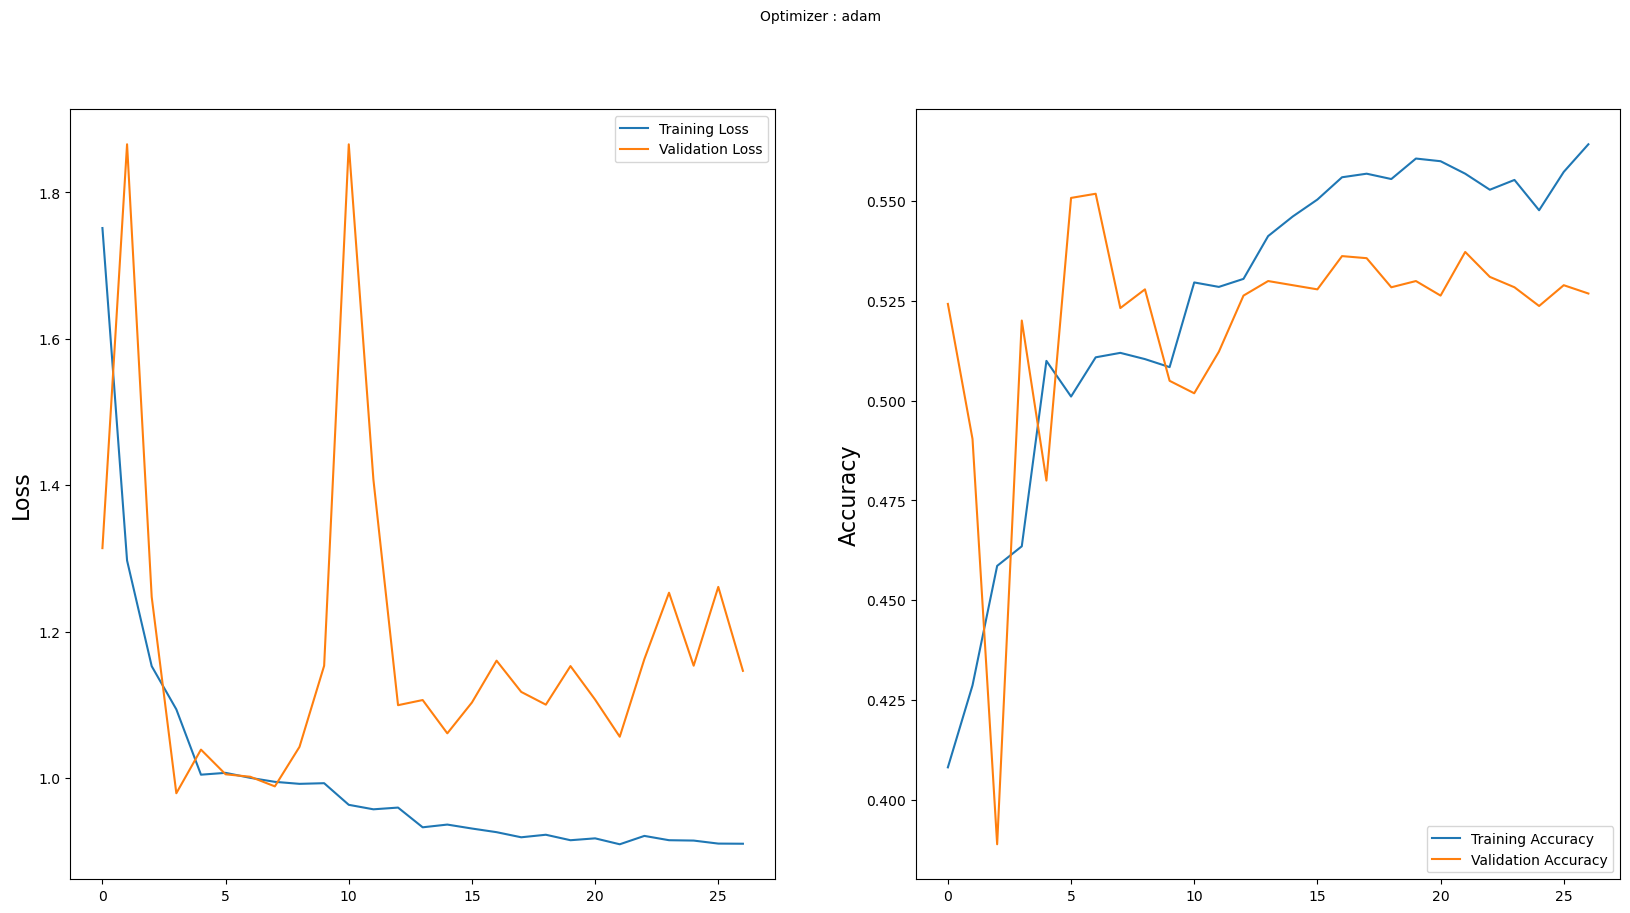

In [17]:
import matplotlib.pyplot as plt

x=hist1
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Xception

In [18]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.layers import Activation, Dense,GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [19]:
base = Xception(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
# Defining the head of the model where the prediction is conducted
head = Dense(4, activation='softmax')(x)
# Combining base and head 
model2 = Model(inputs=base.input, outputs=head)

In [20]:
model2.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
model2.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 63, 63, 32)   864         ['input_2[0][0]']                
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 63, 63, 32)  128         ['block1_conv1[0][0]']           
 ation)                                                                                           
                                                                                            

 n)                                                                                               
                                                                                                  
 block4_sepconv2 (SeparableConv  (None, 16, 16, 728)  536536     ['block4_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block4_sepconv2_bn (BatchNorma  (None, 16, 16, 728)  2912       ['block4_sepconv2[0][0]']        
 lization)                                                                                        
                                                                                                  
 conv2d_96 (Conv2D)             (None, 8, 8, 728)    186368      ['add_1[0][0]']                  
                                                                                                  
 block4_po

                                                                                                  
 block7_sepconv1_bn (BatchNorma  (None, 8, 8, 728)   2912        ['block7_sepconv1[0][0]']        
 lization)                                                                                        
                                                                                                  
 block7_sepconv2_act (Activatio  (None, 8, 8, 728)   0           ['block7_sepconv1_bn[0][0]']     
 n)                                                                                               
                                                                                                  
 block7_sepconv2 (SeparableConv  (None, 8, 8, 728)   536536      ['block7_sepconv2_act[0][0]']    
 2D)                                                                                              
                                                                                                  
 block7_se

                                                                  'add_6[0][0]']                  
                                                                                                  
 block10_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_7[0][0]']                  
 on)                                                                                              
                                                                                                  
 block10_sepconv1 (SeparableCon  (None, 8, 8, 728)   536536      ['block10_sepconv1_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block10_sepconv1_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block10_sepconv1[0][0]']       
 alization)                                                                                       
          

 block12_sepconv3 (SeparableCon  (None, 8, 8, 728)   536536      ['block12_sepconv3_act[0][0]']   
 v2D)                                                                                             
                                                                                                  
 block12_sepconv3_bn (BatchNorm  (None, 8, 8, 728)   2912        ['block12_sepconv3[0][0]']       
 alization)                                                                                       
                                                                                                  
 add_10 (Add)                   (None, 8, 8, 728)    0           ['block12_sepconv3_bn[0][0]',    
                                                                  'add_9[0][0]']                  
                                                                                                  
 block13_sepconv1_act (Activati  (None, 8, 8, 728)   0           ['add_10[0][0]']                 
 on)      

In [21]:
hist2 = model2.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))#,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 59s 25ms/step - loss: 0.9957 - accuracy: 0.5090 - f1_m: 0.3752 - precision_m: 0.5246 - recall_m: 0.3004 - val_loss: 0.8814 - val_accuracy: 0.5789 - val_f1_m: 0.4403 - val_precision_m: 0.5541 - val_recall_m: 0.3835
Epoch 2/100
2240/2240 [==============================] - 54s 24ms/step - loss: 0.9097 - accuracy: 0.5597 - f1_m: 0.4301 - precision_m: 0.5828 - recall_m: 0.3538 - val_loss: 0.8044 - val_accuracy: 0.6096 - val_f1_m: 0.4717 - val_precision_m: 0.5942 - val_recall_m: 0.4105
Epoch 3/100
2240/2240 [==============================] - 54s 24ms/step - loss: 0.8129 - accuracy: 0.6167 - f1_m: 0.4936 - precision_m: 0.6116 - recall_m: 0.4346 - val_loss: 0.9613 - val_accuracy: 0.5513 - val_f1_m: 0.2732 - val_precision_m: 0.3793 - val_recall_m: 0.2201
Epoch 4/100
2240/2240 [==============================] - 54s 24ms/step - loss: 0.7155 - accuracy: 0.6821 - f1_m: 0.5973 - precision_m: 0.6879 - recall_m: 0.5520 - val_loss: 0.6814 - val_a

2240/2240 [==============================] - 53s 24ms/step - loss: 0.0157 - accuracy: 0.9940 - f1_m: 0.9940 - precision_m: 0.9940 - recall_m: 0.9940 - val_loss: 0.0400 - val_accuracy: 0.9859 - val_f1_m: 0.9858 - val_precision_m: 0.9865 - val_recall_m: 0.9854
Epoch 62/100
2240/2240 [==============================] - 54s 24ms/step - loss: 0.0082 - accuracy: 0.9978 - f1_m: 0.9978 - precision_m: 0.9980 - recall_m: 0.9978 - val_loss: 0.1411 - val_accuracy: 0.9573 - val_f1_m: 0.9575 - val_precision_m: 0.9579 - val_recall_m: 0.9573
Epoch 63/100
2240/2240 [==============================] - 54s 24ms/step - loss: 0.0159 - accuracy: 0.9946 - f1_m: 0.9946 - precision_m: 0.9946 - recall_m: 0.9946 - val_loss: 0.0567 - val_accuracy: 0.9802 - val_f1_m: 0.9794 - val_precision_m: 0.9807 - val_recall_m: 0.9787
Epoch 64/100
2240/2240 [==============================] - 54s 24ms/step - loss: 0.0063 - accuracy: 0.9982 - f1_m: 0.9981 - precision_m: 0.9982 - recall_m: 0.9980 - val_loss: 0.0488 - val_accuracy: 

In [22]:
model2.save('xcep.h5')

In [36]:
dl_acc = hist2.history["val_accuracy"][99]
dl_prec = hist2.history["val_precision_m"][99]
dl_rec = hist2.history["val_recall_m"][99]
dl_f1 = hist2.history["val_f1_m"][99]

storeResults('Xception',dl_acc,dl_prec,dl_rec,dl_f1)

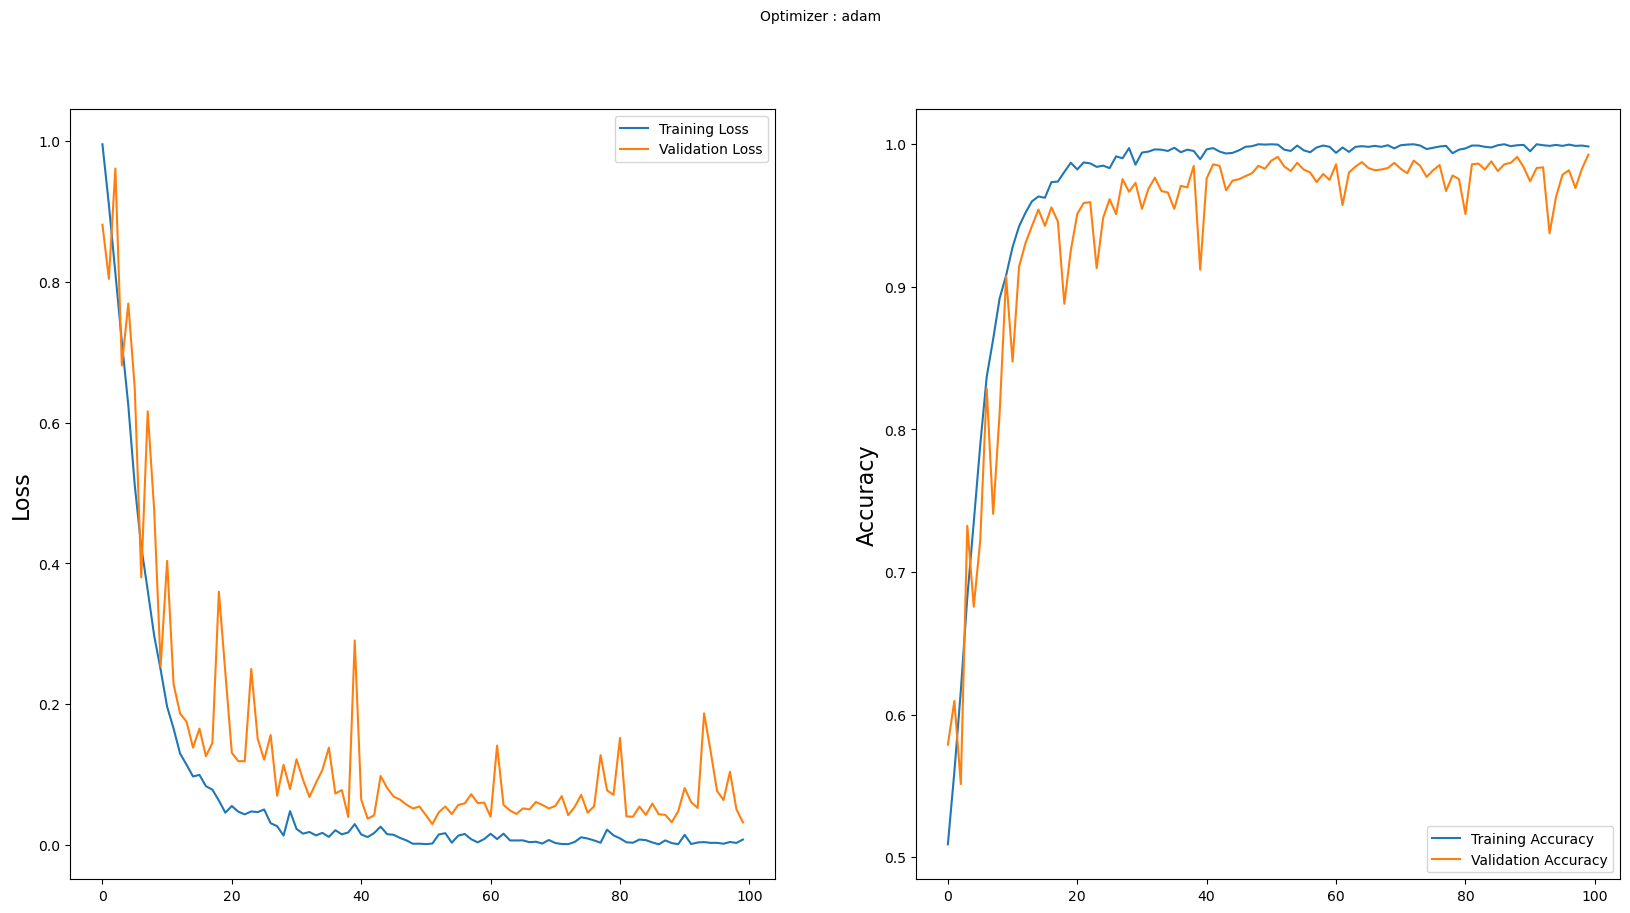

In [24]:
import matplotlib.pyplot as plt

x=hist2
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNet50

In [25]:
base_model = ResNet50(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model3 = Model(inputs = base_model.inputs, outputs = prediction1)
model3.summary()
model3.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_3[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

 conv5_block2_2_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block2_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block2_2_relu[0][0]']    
                                                                                                  
 conv5_block2_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block2_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_out[0][0]',       
                                                                  'conv5_block2_3_bn[0][0]']      
          

In [26]:
hist3 = model3.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 86s 36ms/step - loss: 1.7145 - accuracy: 0.4251 - f1_m: 0.3386 - precision_m: 0.4114 - recall_m: 0.3022 - val_loss: 1.9046 - val_accuracy: 0.4841 - val_f1_m: 0.4837 - val_precision_m: 0.4854 - val_recall_m: 0.4828 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 79s 35ms/step - loss: 1.1142 - accuracy: 0.4604 - f1_m: 0.3007 - precision_m: 0.4054 - recall_m: 0.2484 - val_loss: 1.0416 - val_accuracy: 0.4997 - val_f1_m: 0.5000 - val_precision_m: 0.5000 - val_recall_m: 0.5000 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 79s 35ms/step - loss: 1.0846 - accuracy: 0.4635 - f1_m: 0.3092 - precision_m: 0.4295 - recall_m: 0.2491 - val_loss: 50.7765 - val_accuracy: 0.5003 - val_f1_m: 0.5016 - val_precision_m: 0.5099 - val_recall_m: 0.4974 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 79s 35ms/step - loss: 1.0567 - accuracy: 0.4845 - f1_m: 0.3245 - precision_m: 0.4703 - rec

Epoch 26/100
2239/2240 [============================>.] - ETA: 0s - loss: 0.8624 - accuracy: 0.5747 - f1_m: 0.4216 - precision_m: 0.5498 - recall_m: 0.3575
Epoch 26: ReduceLROnPlateau reducing learning rate to 7.289999985005124e-07.
2240/2240 [==============================] - 79s 35ms/step - loss: 0.8625 - accuracy: 0.5745 - f1_m: 0.4214 - precision_m: 0.5496 - recall_m: 0.3574 - val_loss: 11.2181 - val_accuracy: 0.5185 - val_f1_m: 0.3515 - val_precision_m: 0.4521 - val_recall_m: 0.3012 - lr: 2.4300e-06
Epoch 27/100
2240/2240 [==============================] - 79s 35ms/step - loss: 0.8598 - accuracy: 0.5756 - f1_m: 0.4258 - precision_m: 0.5583 - recall_m: 0.3596 - val_loss: 12.8458 - val_accuracy: 0.5159 - val_f1_m: 0.3535 - val_precision_m: 0.4454 - val_recall_m: 0.3075 - lr: 7.2900e-07
Epoch 28/100
2240/2240 [==============================] - 79s 35ms/step - loss: 0.8644 - accuracy: 0.5749 - f1_m: 0.4217 - precision_m: 0.5556 - recall_m: 0.3547 - val_loss: 13.3024 - val_accuracy: 0.

In [37]:
dl_acc = hist3.history["val_accuracy"][30]
dl_prec = hist3.history["val_precision_m"][30]
dl_rec = hist3.history["val_recall_m"][30]
dl_f1 = hist3.history["val_f1_m"][30]

storeResults('ResNet50',dl_acc,dl_prec,dl_rec,dl_f1)

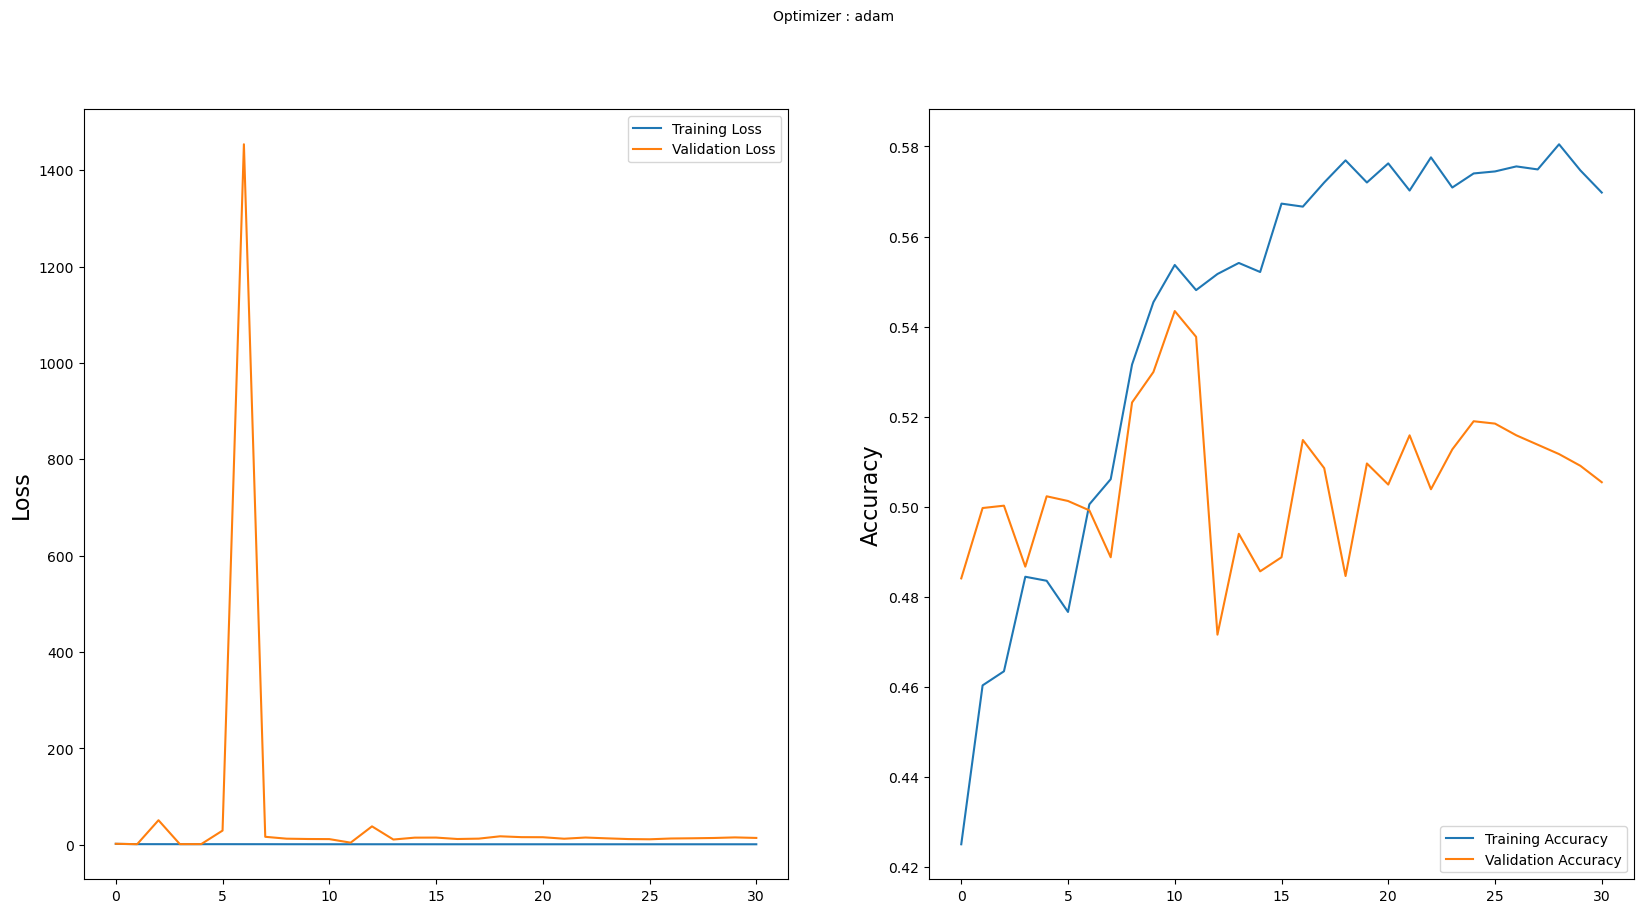

In [27]:
import matplotlib.pyplot as plt

x=hist3
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNet152

In [28]:
base_model = ResNet152(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model4 = Model(inputs = base_model.inputs, outputs = prediction1)
model4.summary()
model4.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_4[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv3_block6_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block6_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block6_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block6_2_relu[0][0]']    
                                                                                                  
 conv3_block6_3_bn (BatchNormal  (None, 16, 16, 512)  2048       ['conv3_block6_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block6_add (Add)         (None, 16, 16, 512)  0           ['conv3_block5_out[0][0]',       
                                                                  'conv3_block6_3_bn[0][0]']      
          

 conv4_block1_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block1_2_relu[0][0]']    
                                                                                                  
 conv4_block1_0_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block1_0_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block1_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block1_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block1_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block1_0_bn[0][0]',      
                                                                  'conv4_block1_3_bn[0][0]']      
          

...

                                                                                                  
 conv4_block27_1_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block27_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block27_1_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block27_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block27_2_conv (Conv2D)  (None, 8, 8, 256)    590080      ['conv4_block27_1_relu[0][0]']   
                                                                                                  
 conv4_block27_2_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block27_2_conv[0][0]']   
 lization)

 on)                                                                                              
                                                                                                  
 conv4_block30_2_conv (Conv2D)  (None, 8, 8, 256)    590080      ['conv4_block30_1_relu[0][0]']   
                                                                                                  
 conv4_block30_2_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block30_2_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block30_2_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block30_2_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_blo

 lization)                                                                                        
                                                                                                  
 conv4_block33_2_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block33_2_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block33_3_conv (Conv2D)  (None, 8, 8, 1024)   263168      ['conv4_block33_2_relu[0][0]']   
                                                                                                  
 conv4_block33_3_bn (BatchNorma  (None, 8, 8, 1024)  4096        ['conv4_block33_3_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_blo

 conv4_block36_3_conv (Conv2D)  (None, 8, 8, 1024)   263168      ['conv4_block36_2_relu[0][0]']   
                                                                                                  
 conv4_block36_3_bn (BatchNorma  (None, 8, 8, 1024)  4096        ['conv4_block36_3_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block36_add (Add)        (None, 8, 8, 1024)   0           ['conv4_block35_out[0][0]',      
                                                                  'conv4_block36_3_bn[0][0]']     
                                                                                                  
 conv4_block36_out (Activation)  (None, 8, 8, 1024)  0           ['conv4_block36_add[0][0]']      
                                                                                                  
 conv5_blo

 conv5_block3_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block3_2_relu[0][0]']    
                                                                                                  
 conv5_block3_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block3_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block3_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block2_out[0][0]',       
                                                                  'conv5_block3_3_bn[0][0]']      
                                                                                                  
 conv5_block3_out (Activation)  (None, 4, 4, 2048)   0           ['conv5_block3_add[0][0]']       
                                                                                                  
 flatten_2

In [29]:
hist4 = model4.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 224s 93ms/step - loss: 1.6341 - accuracy: 0.4403 - f1_m: 0.3324 - precision_m: 0.4065 - recall_m: 0.2953 - val_loss: 156.9785 - val_accuracy: 0.4794 - val_f1_m: 0.2945 - val_precision_m: 0.3809 - val_recall_m: 0.2513 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 206s 92ms/step - loss: 1.0621 - accuracy: 0.4818 - f1_m: 0.2327 - precision_m: 0.3098 - recall_m: 0.1942 - val_loss: 1.1863 - val_accuracy: 0.4862 - val_f1_m: 0.2114 - val_precision_m: 0.2856 - val_recall_m: 0.1743 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 206s 92ms/step - loss: 1.0931 - accuracy: 0.4729 - f1_m: 0.2914 - precision_m: 0.3732 - recall_m: 0.2504 - val_loss: 1.1115 - val_accuracy: 0.4388 - val_f1_m: 0.0132 - val_precision_m: 0.0198 - val_recall_m: 0.0099 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 207s 92ms/step - loss: 1.2923 - accuracy: 0.4568 - f1_m: 0.2921 - precision_m: 0.3888 

Epoch 28/100
2240/2240 [==============================] - 206s 92ms/step - loss: 0.8577 - accuracy: 0.5872 - f1_m: 0.4475 - precision_m: 0.5712 - recall_m: 0.3857 - val_loss: 1.4536 - val_accuracy: 0.5752 - val_f1_m: 0.4556 - val_precision_m: 0.5656 - val_recall_m: 0.4006 - lr: 9.0000e-05
Epoch 29/100
2240/2240 [==============================] - 206s 92ms/step - loss: 0.8598 - accuracy: 0.5832 - f1_m: 0.4420 - precision_m: 0.5679 - recall_m: 0.3790 - val_loss: 2.3167 - val_accuracy: 0.5966 - val_f1_m: 0.4674 - val_precision_m: 0.5874 - val_recall_m: 0.4074 - lr: 9.0000e-05
Epoch 30/100
2240/2240 [==============================] - 204s 91ms/step - loss: 0.8477 - accuracy: 0.5990 - f1_m: 0.4612 - precision_m: 0.5844 - recall_m: 0.3996 - val_loss: 5.9017 - val_accuracy: 0.5747 - val_f1_m: 0.4632 - val_precision_m: 0.5666 - val_recall_m: 0.4116 - lr: 9.0000e-05
Epoch 31/100
2240/2240 [==============================] - 202s 90ms/step - loss: 0.8429 - accuracy: 0.5843 - f1_m: 0.4608 - precis

In [38]:
dl_acc = hist4.history["val_accuracy"][48]
dl_prec = hist4.history["val_precision_m"][48]
dl_rec = hist4.history["val_recall_m"][48]
dl_f1 = hist4.history["val_f1_m"][48]

storeResults('ResNet152',dl_acc,dl_prec,dl_rec,dl_f1)

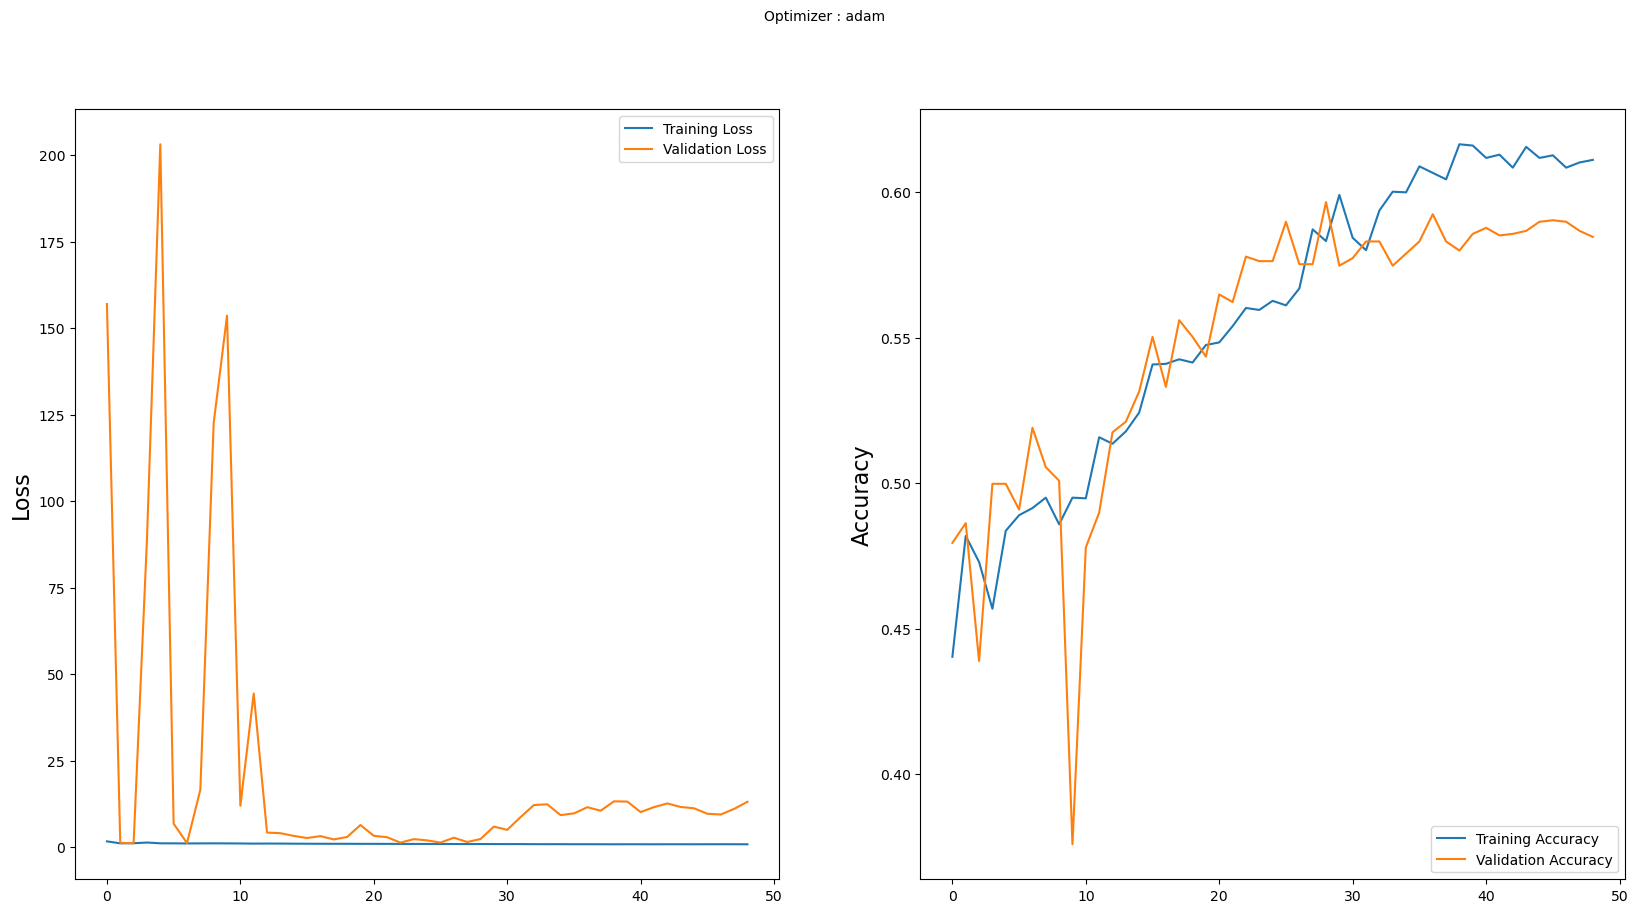

In [30]:
import matplotlib.pyplot as plt

x=hist4
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNet101

In [31]:
base_model = ResNet101(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model5 = Model(inputs = base_model.inputs, outputs = prediction1)
model5.summary()
model5.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_4"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_5[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1_conv[0][0]']       

 conv2_block3_2_conv (Conv2D)   (None, 32, 32, 64)   36928       ['conv2_block3_1_relu[0][0]']    
                                                                                                  
 conv2_block3_2_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_2_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block3_3_conv (Conv2D)   (None, 32, 32, 256)  16640       ['conv2_block3_2_relu[0][0]']    
                                                                                                  
 conv2_blo

 conv3_block3_2_conv (Conv2D)   (None, 16, 16, 128)  147584      ['conv3_block3_1_relu[0][0]']    
                                                                                                  
 conv3_block3_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block3_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block3_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block3_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block3_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block3_2_relu[0][0]']    
                                                                                                  
 conv3_blo

 conv4_block2_2_conv (Conv2D)   (None, 8, 8, 256)    590080      ['conv4_block2_1_relu[0][0]']    
                                                                                                  
 conv4_block2_2_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block2_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block2_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block2_2_relu[0][0]']    
                                                                                                  
 conv4_blo

 conv4_block5_2_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block5_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block5_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block5_2_relu[0][0]']    
                                                                                                  
 conv4_block5_3_bn (BatchNormal  (None, 8, 8, 1024)  4096        ['conv4_block5_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block5_add (Add)         (None, 8, 8, 1024)   0           ['conv4_block4_out[0][0]',       
                                                                  'conv4_block5_3_bn[0][0]']      
          

...

                                                                                                  
 conv4_block11_out (Activation)  (None, 8, 8, 1024)  0           ['conv4_block11_add[0][0]']      
                                                                                                  
 conv4_block12_1_conv (Conv2D)  (None, 8, 8, 256)    262400      ['conv4_block11_out[0][0]']      
                                                                                                  
 conv4_block12_1_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block12_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block12_1_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block12_1_bn[0][0]']     
 on)                                                                                              
          

 conv4_block15_1_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block15_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block15_1_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block15_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block15_2_conv (Conv2D)  (None, 8, 8, 256)    590080      ['conv4_block15_1_relu[0][0]']   
                                                                                                  
 conv4_block15_2_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block15_2_conv[0][0]']   
 lization)                                                                                        
          

                                                                                                  
 conv4_block18_2_conv (Conv2D)  (None, 8, 8, 256)    590080      ['conv4_block18_1_relu[0][0]']   
                                                                                                  
 conv4_block18_2_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block18_2_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block18_2_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block18_2_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block18_3_conv (Conv2D)  (None, 8, 8, 1024)   263168      ['conv4_block18_2_relu[0][0]']   
          

                                                                                                  
 conv4_block21_2_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block21_2_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block21_3_conv (Conv2D)  (None, 8, 8, 1024)   263168      ['conv4_block21_2_relu[0][0]']   
                                                                                                  
 conv4_block21_3_bn (BatchNorma  (None, 8, 8, 1024)  4096        ['conv4_block21_3_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block21_add (Add)        (None, 8, 8, 1024)   0           ['conv4_block20_out[0][0]',      
          

                                                                                                  
 conv5_block1_3_conv (Conv2D)   (None, 4, 4, 2048)   1050624     ['conv5_block1_2_relu[0][0]']    
                                                                                                  
 conv5_block1_0_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block1_0_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block1_3_bn (BatchNormal  (None, 4, 4, 2048)  8192        ['conv5_block1_3_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block1_add (Add)         (None, 4, 4, 2048)   0           ['conv5_block1_0_bn[0][0]',      
          

In [32]:
hist5 = model5.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 153s 64ms/step - loss: 1.5965 - accuracy: 0.4392 - f1_m: 0.3251 - precision_m: 0.4069 - recall_m: 0.2842 - val_loss: 1.1688 - val_accuracy: 0.3498 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 145s 65ms/step - loss: 1.1379 - accuracy: 0.4724 - f1_m: 0.3070 - precision_m: 0.3996 - recall_m: 0.2607 - val_loss: 406.8565 - val_accuracy: 0.5008 - val_f1_m: 0.4941 - val_precision_m: 0.5083 - val_recall_m: 0.4870 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 140s 63ms/step - loss: 1.0745 - accuracy: 0.4860 - f1_m: 0.2525 - precision_m: 0.3261 - recall_m: 0.2156 - val_loss: 1.7209 - val_accuracy: 0.4997 - val_f1_m: 0.4518 - val_precision_m: 0.5042 - val_recall_m: 0.4256 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 140s 63ms/step - loss: 1.0863 - accuracy: 0.4782 - f1_m: 0.3088 - precisio

Epoch 26/100
2240/2240 [==============================] - 139s 62ms/step - loss: 0.9192 - accuracy: 0.5481 - f1_m: 0.3741 - precision_m: 0.5277 - recall_m: 0.2973 - val_loss: 4.4374 - val_accuracy: 0.5778 - val_f1_m: 0.3684 - val_precision_m: 0.4870 - val_recall_m: 0.3091 - lr: 2.4300e-06
Epoch 27/100
2240/2240 [==============================] - 139s 62ms/step - loss: 0.9209 - accuracy: 0.5503 - f1_m: 0.3846 - precision_m: 0.5404 - recall_m: 0.3067 - val_loss: 5.4755 - val_accuracy: 0.5742 - val_f1_m: 0.3628 - val_precision_m: 0.4745 - val_recall_m: 0.3070 - lr: 2.4300e-06
Epoch 28/100
2240/2240 [==============================] - 145s 65ms/step - loss: 0.9109 - accuracy: 0.5570 - f1_m: 0.3882 - precision_m: 0.5460 - recall_m: 0.3094 - val_loss: 3.8428 - val_accuracy: 0.5846 - val_f1_m: 0.3803 - val_precision_m: 0.5042 - val_recall_m: 0.3184 - lr: 2.4300e-06
Epoch 29/100
2240/2240 [==============================] - 140s 62ms/step - loss: 0.9066 - accuracy: 0.5550 - f1_m: 0.3949 - precis

In [39]:
dl_acc = hist5.history["val_accuracy"][47]
dl_prec = hist5.history["val_precision_m"][47]
dl_rec = hist5.history["val_recall_m"][47]
dl_f1 = hist5.history["val_f1_m"][47]

storeResults('ResNet101',dl_acc,dl_prec,dl_rec,dl_f1)

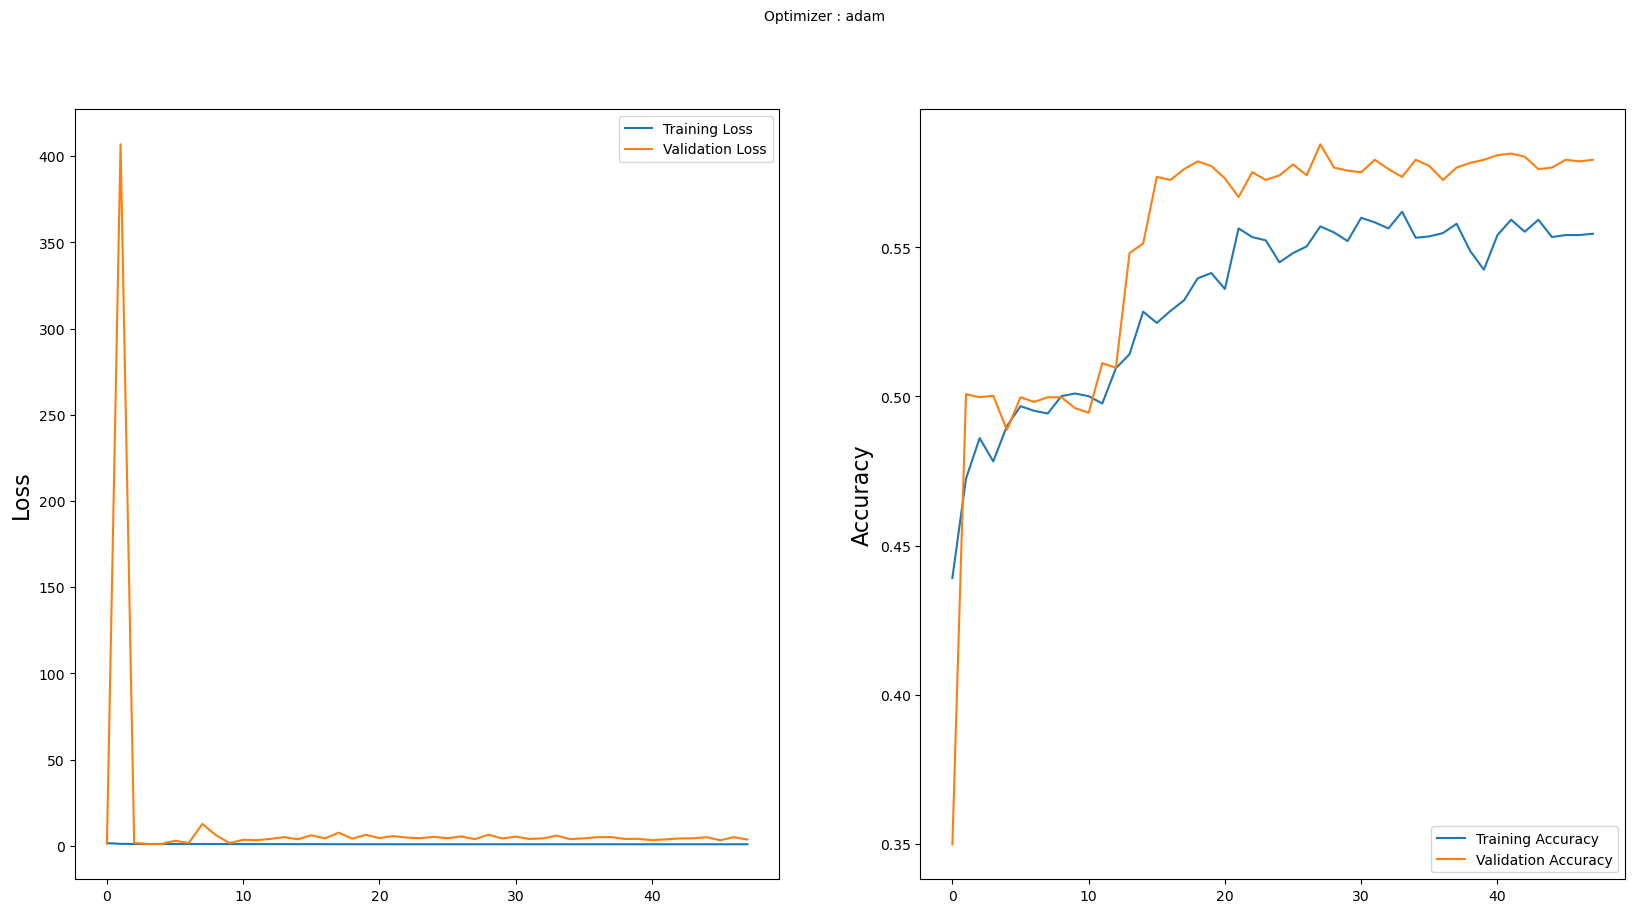

In [33]:
import matplotlib.pyplot as plt

x=hist5
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# ResNetX008/V2

In [34]:
base_model = ResNet101V2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model6 = Model(inputs = base_model.inputs, outputs = prediction1)
model6.summary()
model6.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_6 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 134, 134, 3)  0           ['input_6[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 64, 64, 64)   9472        ['conv1_pad[0][0]']              
                                                                                                  
 pool1_pad (ZeroPadding2D)      (None, 66, 66, 64)   0           ['conv1_conv[0][0]']       

 vation)                                                                                          
                                                                                                  
 conv2_block3_1_conv (Conv2D)   (None, 32, 32, 64)   16384       ['conv2_block3_preact_relu[0][0]'
                                                                 ]                                
                                                                                                  
 conv2_block3_1_bn (BatchNormal  (None, 32, 32, 64)  256         ['conv2_block3_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block3_1_relu (Activatio  (None, 32, 32, 64)  0           ['conv2_block3_1_bn[0][0]']      
 n)                                                                                               
          

 conv3_block2_2_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_2_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_2_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_2_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_3_conv (Conv2D)   (None, 16, 16, 512)  66048       ['conv3_block2_2_relu[0][0]']    
                                                                                                  
 conv3_block2_out (Add)         (None, 16, 16, 512)  0           ['conv3_block1_out[0][0]',       
                                                                  'conv3_block2_3_conv[0][0]']    
          

                                                                                                  
 conv4_block1_1_bn (BatchNormal  (None, 8, 8, 256)   1024        ['conv4_block1_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv4_block1_1_relu (Activatio  (None, 8, 8, 256)   0           ['conv4_block1_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv4_block1_2_pad (ZeroPaddin  (None, 10, 10, 256)  0          ['conv4_block1_1_relu[0][0]']    
 g2D)                                                                                             
                                                                                                  
 conv4_blo

 conv4_block3_3_conv (Conv2D)   (None, 8, 8, 1024)   263168      ['conv4_block3_2_relu[0][0]']    
                                                                                                  
 conv4_block3_out (Add)         (None, 8, 8, 1024)   0           ['conv4_block2_out[0][0]',       
                                                                  'conv4_block3_3_conv[0][0]']    
                                                                                                  
 conv4_block4_preact_bn (BatchN  (None, 8, 8, 1024)  4096        ['conv4_block3_out[0][0]']       
 ormalization)                                                                                    
                                                                                                  
 conv4_block4_preact_relu (Acti  (None, 8, 8, 1024)  0           ['conv4_block4_preact_bn[0][0]'] 
 vation)                                                                                          
          

...

                                                                                                  
 conv4_block14_2_conv (Conv2D)  (None, 8, 8, 256)    589824      ['conv4_block14_2_pad[0][0]']    
                                                                                                  
 conv4_block14_2_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block14_2_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block14_2_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block14_2_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block14_3_conv (Conv2D)  (None, 8, 8, 1024)   263168      ['conv4_block14_2_relu[0][0]']   
          

                                                                 ']                               
                                                                                                  
 conv4_block17_1_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block17_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block17_1_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block17_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block17_2_pad (ZeroPaddi  (None, 10, 10, 256)  0          ['conv4_block17_1_relu[0][0]']   
 ng2D)                                                                                            
          

 conv4_block19_out (Add)        (None, 8, 8, 1024)   0           ['conv4_block18_out[0][0]',      
                                                                  'conv4_block19_3_conv[0][0]']   
                                                                                                  
 conv4_block20_preact_bn (Batch  (None, 8, 8, 1024)  4096        ['conv4_block19_out[0][0]']      
 Normalization)                                                                                   
                                                                                                  
 conv4_block20_preact_relu (Act  (None, 8, 8, 1024)  0           ['conv4_block20_preact_bn[0][0]']
 ivation)                                                                                         
                                                                                                  
 conv4_block20_1_conv (Conv2D)  (None, 8, 8, 256)    262144      ['conv4_block20_preact_relu[0][0]
          

 conv4_block22_2_conv (Conv2D)  (None, 8, 8, 256)    589824      ['conv4_block22_2_pad[0][0]']    
                                                                                                  
 conv4_block22_2_bn (BatchNorma  (None, 8, 8, 256)   1024        ['conv4_block22_2_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv4_block22_2_relu (Activati  (None, 8, 8, 256)   0           ['conv4_block22_2_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block22_3_conv (Conv2D)  (None, 8, 8, 1024)   263168      ['conv4_block22_2_relu[0][0]']   
                                                                                                  
 conv4_blo

 conv5_block2_preact_relu (Acti  (None, 4, 4, 2048)  0           ['conv5_block2_preact_bn[0][0]'] 
 vation)                                                                                          
                                                                                                  
 conv5_block2_1_conv (Conv2D)   (None, 4, 4, 512)    1048576     ['conv5_block2_preact_relu[0][0]'
                                                                 ]                                
                                                                                                  
 conv5_block2_1_bn (BatchNormal  (None, 4, 4, 512)   2048        ['conv5_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block2_1_relu (Activatio  (None, 4, 4, 512)   0           ['conv5_block2_1_bn[0][0]']      
 n)       

In [35]:
hist6 = model6.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 140s 58ms/step - loss: 1.8083 - accuracy: 0.4447 - f1_m: 0.2926 - precision_m: 0.4181 - recall_m: 0.2299 - val_loss: 1.4500 - val_accuracy: 0.4935 - val_f1_m: 0.4731 - val_precision_m: 0.4880 - val_recall_m: 0.4657 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 128s 57ms/step - loss: 1.6146 - accuracy: 0.4485 - f1_m: 0.2906 - precision_m: 0.4007 - recall_m: 0.2355 - val_loss: 51.9465 - val_accuracy: 0.3800 - val_f1_m: 0.3803 - val_precision_m: 0.3803 - val_recall_m: 0.3803 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 129s 57ms/step - loss: 1.2639 - accuracy: 0.4655 - f1_m: 0.2405 - precision_m: 0.3469 - recall_m: 0.1873 - val_loss: 3.8085 - val_accuracy: 0.4997 - val_f1_m: 6.9372e-04 - val_precision_m: 0.0010 - val_recall_m: 5.2029e-04 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 128s 57ms/step - loss: 1.3611 - accuracy: 0.4601 - f1_m: 0.2600 - precision_m: 

Epoch 27/100
2240/2240 [==============================] - ETA: 0s - loss: 1.0062 - accuracy: 0.5057 - f1_m: 0.3599 - precision_m: 0.5025 - recall_m: 0.2886
Epoch 27: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
2240/2240 [==============================] - 128s 57ms/step - loss: 1.0062 - accuracy: 0.5057 - f1_m: 0.3599 - precision_m: 0.5025 - recall_m: 0.2886 - val_loss: 1167.4806 - val_accuracy: 0.5091 - val_f1_m: 0.2773 - val_precision_m: 0.3699 - val_recall_m: 0.2310 - lr: 2.7000e-05
Epoch 28/100
2240/2240 [==============================] - 129s 58ms/step - loss: 1.0061 - accuracy: 0.5128 - f1_m: 0.3538 - precision_m: 0.4958 - recall_m: 0.2828 - val_loss: 1173.9133 - val_accuracy: 0.5112 - val_f1_m: 0.2811 - val_precision_m: 0.3741 - val_recall_m: 0.2347 - lr: 8.1000e-06
Epoch 29/100
2240/2240 [==============================] - 128s 57ms/step - loss: 1.0048 - accuracy: 0.4988 - f1_m: 0.3623 - precision_m: 0.5060 - recall_m: 0.2904 - val_loss: 938.7737 - val_accu

In [40]:
dl_acc = hist6.history["val_accuracy"][52]
dl_prec = hist6.history["val_precision_m"][52]
dl_rec = hist6.history["val_recall_m"][52]
dl_f1 = hist6.history["val_f1_m"][52]

storeResults('ResNet008/V2',dl_acc,dl_prec,dl_rec,dl_f1)

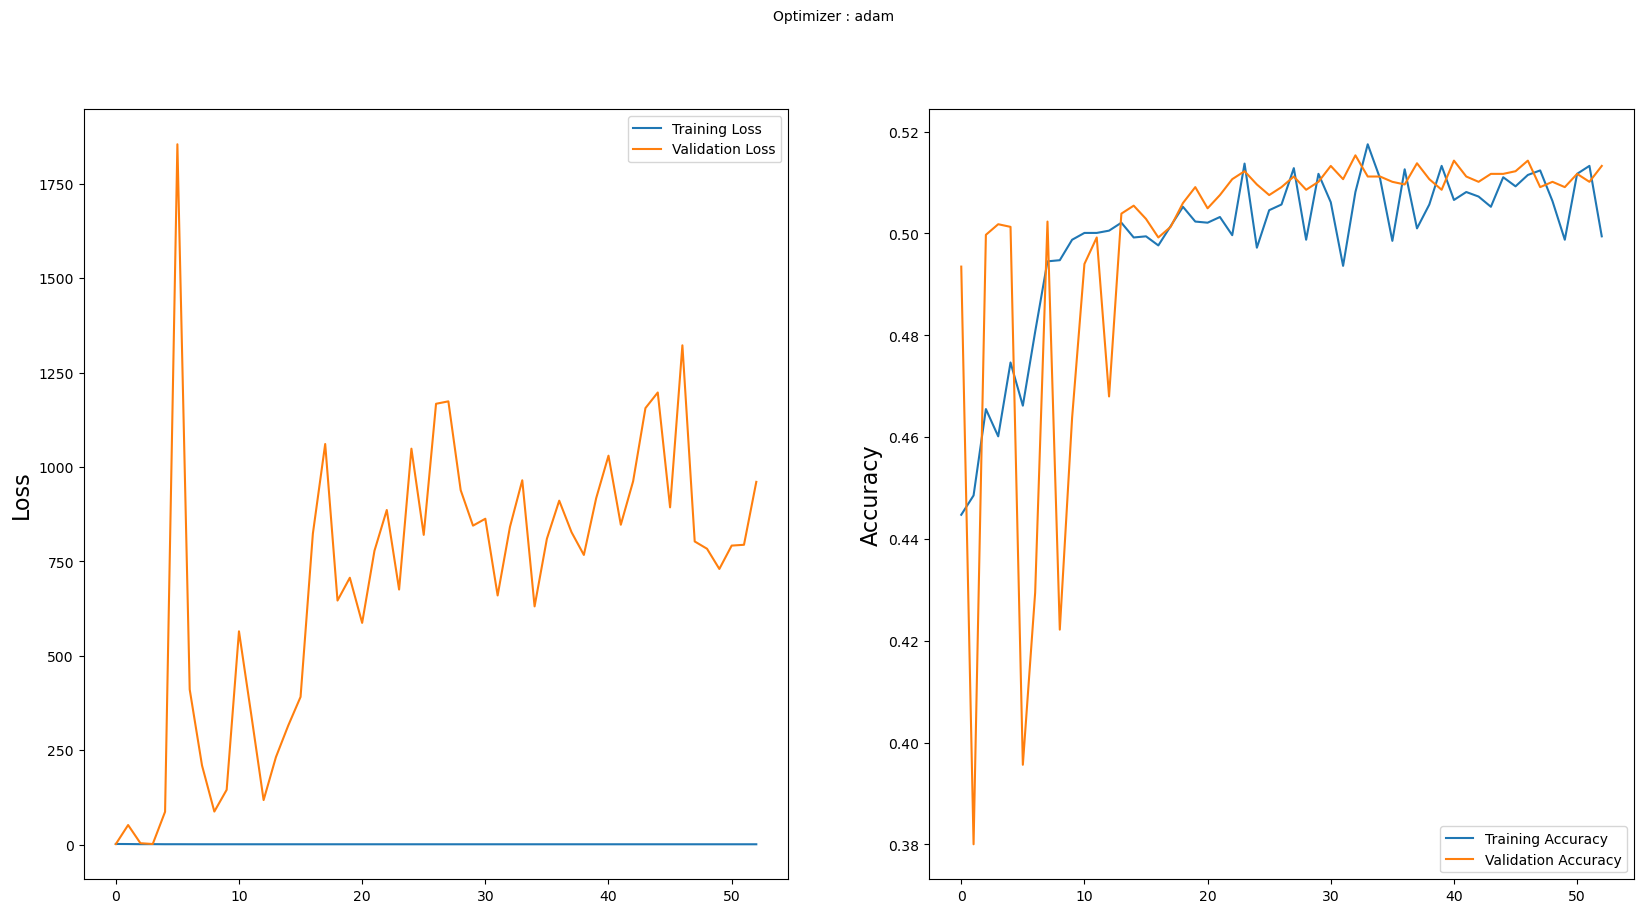

In [36]:
import matplotlib.pyplot as plt

x=hist6
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# InceptionResNetV2

In [37]:
base_model = InceptionResNetV2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model7 = Model(inputs = base_model.inputs, outputs = prediction1)
model7.summary()
model7.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_7 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_98 (Conv2D)             (None, 63, 63, 32)   864         ['input_7[0][0]']                
                                                                                                  
 batch_normalization_98 (BatchN  (None, 63, 63, 32)  96          ['conv2d_98[0][0]']              
 ormalization)                                                                                    
                                                                                            

 batch_normalization_108 (Batch  (None, 13, 13, 96)  288         ['conv2d_108[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_normalization_109 (Batch  (None, 13, 13, 64)  192         ['conv2d_109[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_99 (Activation)     (None, 13, 13, 96)   0           ['batch_normalization_103[0][0]']
                                                                                                  
 activation_101 (Activation)    (None, 13, 13, 64)   0           ['batch_normalization_105[0][0]']
                                                                                                  
 activatio

 batch_normalization_117 (Batch  (None, 13, 13, 32)  96          ['conv2d_117[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_normalization_120 (Batch  (None, 13, 13, 48)  144         ['conv2d_120[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_113 (Activation)    (None, 13, 13, 32)   0           ['batch_normalization_117[0][0]']
                                                                                                  
 activation_116 (Activation)    (None, 13, 13, 48)   0           ['batch_normalization_120[0][0]']
                                                                                                  
 conv2d_11

                                                                                                  
 block35_3_mixed (Concatenate)  (None, 13, 13, 128)  0           ['activation_118[0][0]',         
                                                                  'activation_120[0][0]',         
                                                                  'activation_123[0][0]']         
                                                                                                  
 block35_3_conv (Conv2D)        (None, 13, 13, 320)  41280       ['block35_3_mixed[0][0]']        
                                                                                                  
 block35_3 (Lambda)             (None, 13, 13, 320)  0           ['block35_2_ac[0][0]',           
                                                                  'block35_3_conv[0][0]']         
                                                                                                  
 block35_3

                                                                                                  
 activation_134 (Activation)    (None, 13, 13, 48)   0           ['batch_normalization_138[0][0]']
                                                                                                  
 conv2d_134 (Conv2D)            (None, 13, 13, 32)   10240       ['block35_4_ac[0][0]']           
                                                                                                  
 conv2d_136 (Conv2D)            (None, 13, 13, 32)   9216        ['activation_131[0][0]']         
                                                                                                  
 conv2d_139 (Conv2D)            (None, 13, 13, 64)   27648       ['activation_134[0][0]']         
                                                                                                  
 batch_normalization_134 (Batch  (None, 13, 13, 32)  96          ['conv2d_134[0][0]']             
 Normaliza

...

                                                                                                  
 activation_259 (Activation)    (None, 2, 2, 224)    0           ['batch_normalization_263[0][0]']
                                                                                                  
 conv2d_261 (Conv2D)            (None, 2, 2, 192)    399360      ['mixed_7a[0][0]']               
                                                                                                  
 conv2d_264 (Conv2D)            (None, 2, 2, 256)    172032      ['activation_259[0][0]']         
                                                                                                  
 batch_normalization_261 (Batch  (None, 2, 2, 192)   576         ['conv2d_261[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_nor

 batch_normalization_269 (Batch  (None, 2, 2, 192)   576         ['conv2d_269[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 batch_normalization_272 (Batch  (None, 2, 2, 256)   768         ['conv2d_272[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_265 (Activation)    (None, 2, 2, 192)    0           ['batch_normalization_269[0][0]']
                                                                                                  
 activation_268 (Activation)    (None, 2, 2, 256)    0           ['batch_normalization_272[0][0]']
                                                                                                  
 block8_3_

                                                                                                  
 activation_276 (Activation)    (None, 2, 2, 256)    0           ['batch_normalization_280[0][0]']
                                                                                                  
 block8_5_mixed (Concatenate)   (None, 2, 2, 448)    0           ['activation_273[0][0]',         
                                                                  'activation_276[0][0]']         
                                                                                                  
 block8_5_conv (Conv2D)         (None, 2, 2, 2080)   933920      ['block8_5_mixed[0][0]']         
                                                                                                  
 block8_5 (Lambda)              (None, 2, 2, 2080)   0           ['block8_4_ac[0][0]',            
                                                                  'block8_5_conv[0][0]']          
          

                                                                                                  
 block8_7 (Lambda)              (None, 2, 2, 2080)   0           ['block8_6_ac[0][0]',            
                                                                  'block8_7_conv[0][0]']          
                                                                                                  
 block8_7_ac (Activation)       (None, 2, 2, 2080)   0           ['block8_7[0][0]']               
                                                                                                  
 conv2d_290 (Conv2D)            (None, 2, 2, 192)    399360      ['block8_7_ac[0][0]']            
                                                                                                  
 batch_normalization_290 (Batch  (None, 2, 2, 192)   576         ['conv2d_290[0][0]']             
 Normalization)                                                                                   
          

                                                                                                  
 batch_normalization_298 (Batch  (None, 2, 2, 192)   576         ['conv2d_298[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_294 (Activation)    (None, 2, 2, 192)    0           ['batch_normalization_298[0][0]']
                                                                                                  
 conv2d_299 (Conv2D)            (None, 2, 2, 224)    129024      ['activation_294[0][0]']         
                                                                                                  
 batch_normalization_299 (Batch  (None, 2, 2, 224)   672         ['conv2d_299[0][0]']             
 Normalization)                                                                                   
          

In [38]:
hist7 = model7.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 267s 112ms/step - loss: 1.5192 - accuracy: 0.4331 - f1_m: 0.3815 - precision_m: 0.4237 - recall_m: 0.3605 - val_loss: 1.1105 - val_accuracy: 0.4997 - val_f1_m: 0.4953 - val_precision_m: 0.5120 - val_recall_m: 0.4870 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 248s 111ms/step - loss: 1.3608 - accuracy: 0.4450 - f1_m: 0.3452 - precision_m: 0.4040 - recall_m: 0.3158 - val_loss: 1.8754 - val_accuracy: 0.4305 - val_f1_m: 0.0456 - val_precision_m: 0.0661 - val_recall_m: 0.0354 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 249s 111ms/step - loss: 1.1807 - accuracy: 0.4668 - f1_m: 0.3436 - precision_m: 0.4241 - recall_m: 0.3033 - val_loss: 6.7772 - val_accuracy: 0.4982 - val_f1_m: 0.3269 - val_precision_m: 0.4168 - val_recall_m: 0.2820 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - ETA: 0s - loss: 1.1519 - accuracy: 0.4682 - f1_m: 0.3625 - precision_m: 0.4455 - reca

In [41]:
dl_acc = hist7.history["val_accuracy"][36]
dl_prec = hist7.history["val_precision_m"][36]
dl_rec = hist7.history["val_recall_m"][36]
dl_f1 = hist7.history["val_f1_m"][36]

storeResults('InceptionResNetV2',dl_acc,dl_prec,dl_rec,dl_f1)

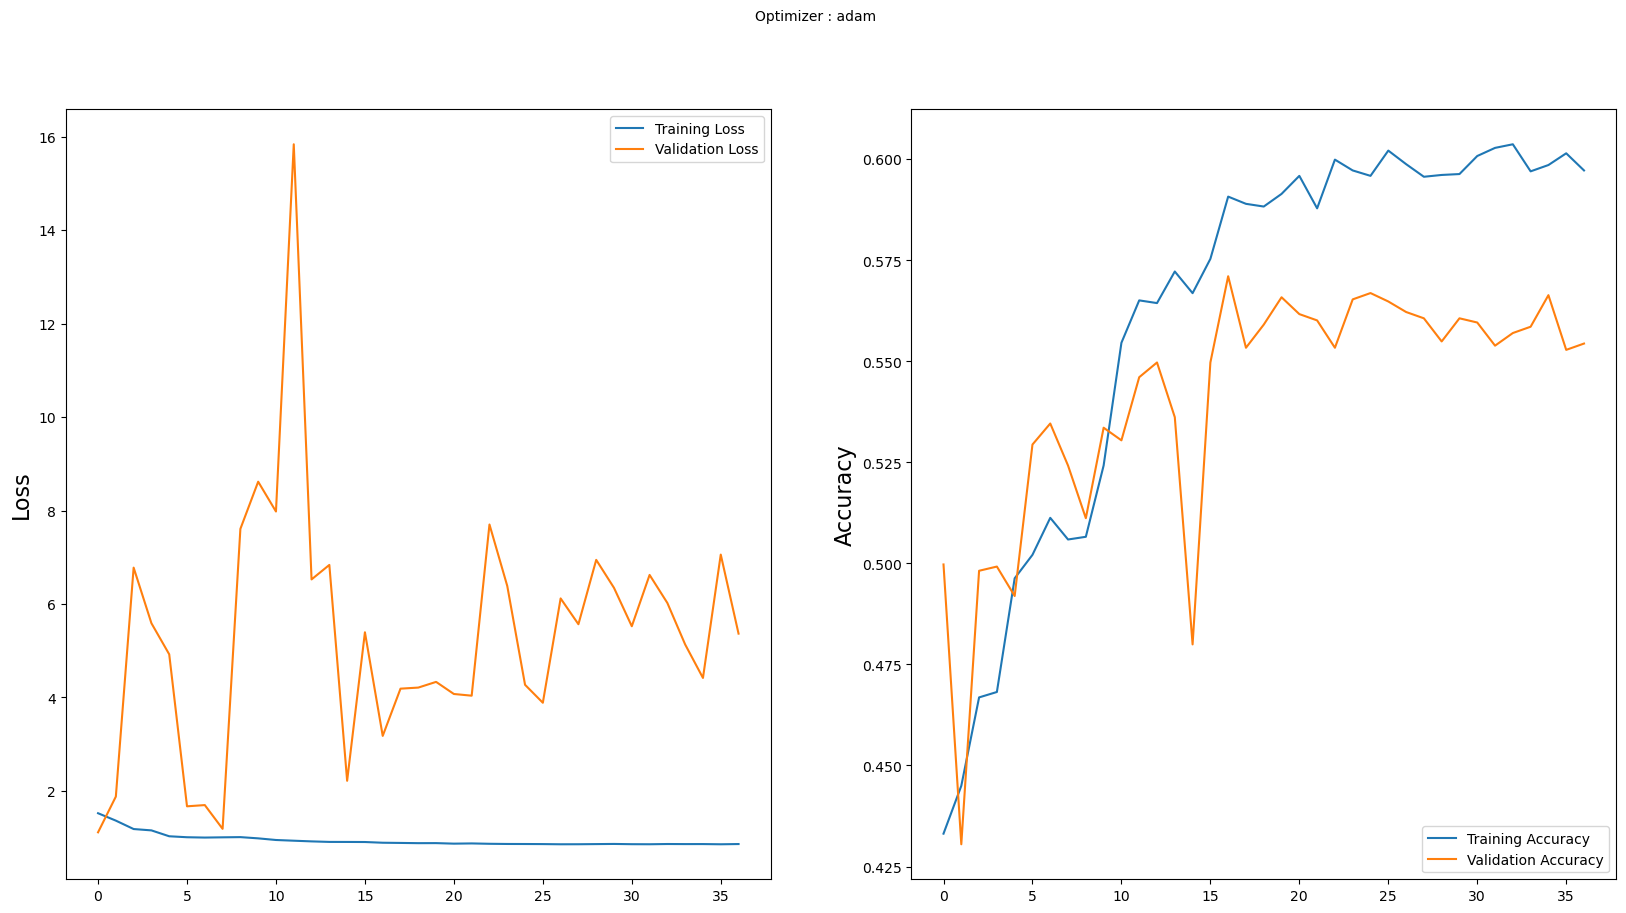

In [39]:
import matplotlib.pyplot as plt

x=hist7
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# VGG19

In [40]:
base_model = VGG19(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model8 = Model(inputs = base_model.inputs, outputs = prediction1)
model8.summary()
model8.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [41]:
hist8 = model8.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 30s 13ms/step - loss: 1.2089 - accuracy: 0.4769 - f1_m: 0.2551 - precision_m: 0.2554 - recall_m: 0.2549 - val_loss: 1.0396 - val_accuracy: 0.4997 - val_f1_m: 0.4995 - val_precision_m: 0.4995 - val_recall_m: 0.4995 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 28s 12ms/step - loss: 1.0444 - accuracy: 0.4965 - f1_m: 0.2208 - precision_m: 0.2208 - recall_m: 0.2208 - val_loss: 1.0375 - val_accuracy: 0.4997 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 28s 12ms/step - loss: 1.0424 - accuracy: 0.4994 - f1_m: 0.2248 - precision_m: 0.2248 - recall_m: 0.2248 - val_loss: 1.0380 - val_accuracy: 0.4997 - val_f1_m: 0.0000e+00 - val_precision_m: 0.0000e+00 - val_recall_m: 0.0000e+00 - lr: 0.0010
Epoch 4/100
2239/2240 [============================>.] - ETA: 0s - loss: 1.0422 - accuracy: 0.5001 - f1_m: 0.2193 - precisio

In [42]:
dl_acc = hist8.history["val_accuracy"][20]
dl_prec = hist8.history["val_precision_m"][20]
dl_rec = hist8.history["val_recall_m"][20]
dl_f1 = hist8.history["val_f1_m"][20]

storeResults('VGG19',dl_acc,dl_prec,dl_rec,dl_f1)

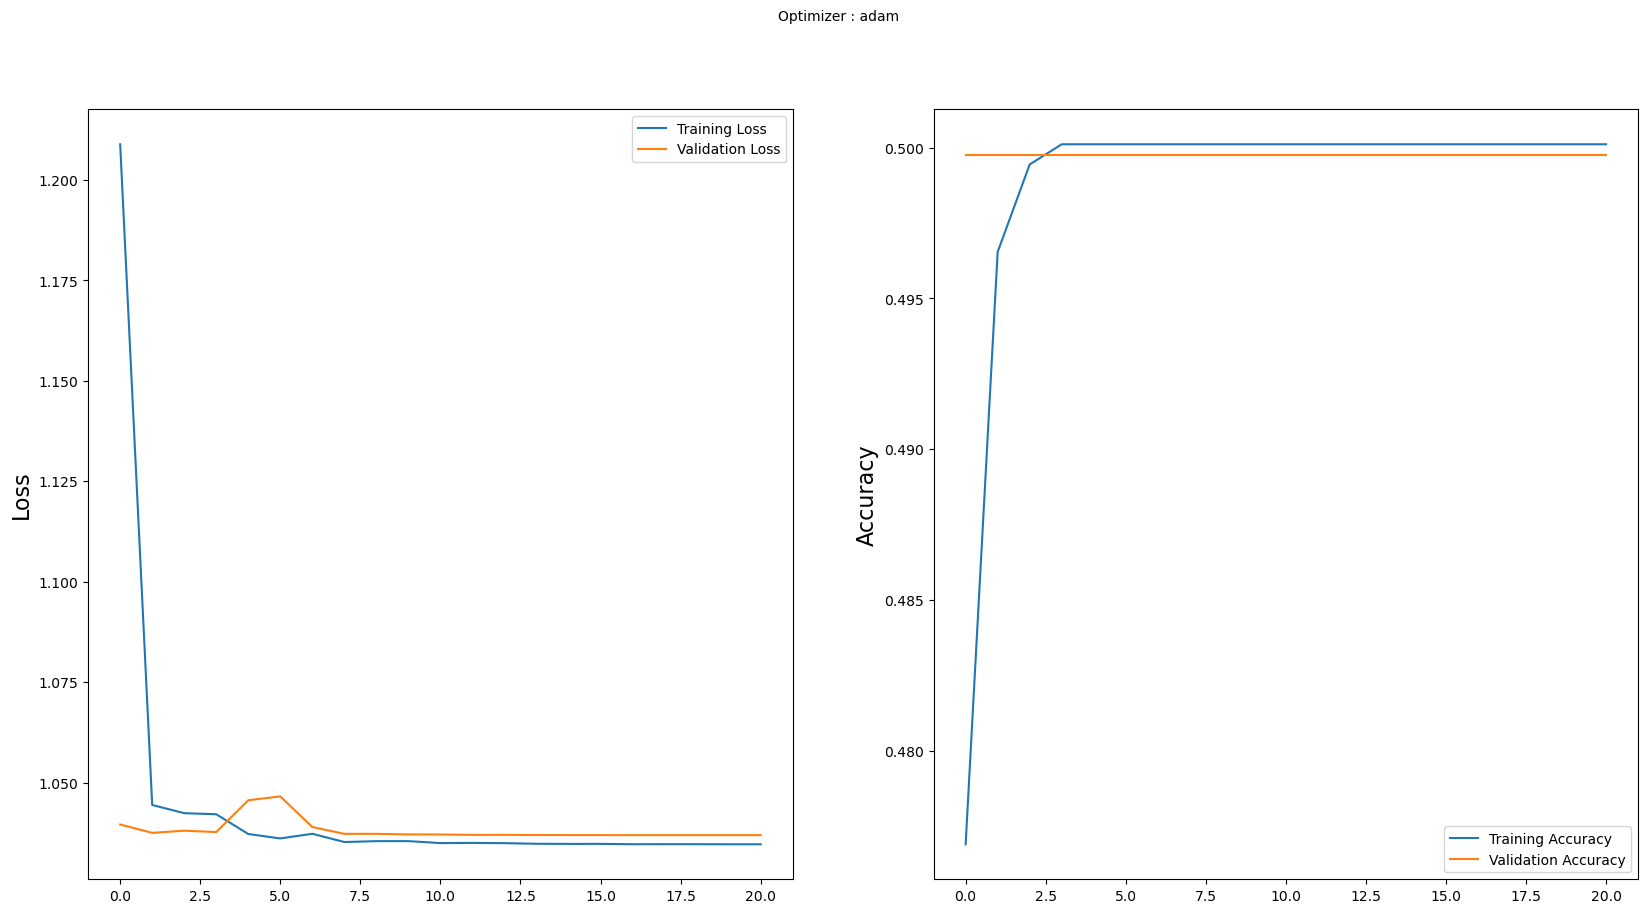

In [42]:
import matplotlib.pyplot as plt

x=hist8
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# MobileNetV2

In [43]:
base_model = MobileNetV2(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model9 = Model(inputs = base_model.inputs, outputs = prediction1)
model9.summary()
model9.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_9 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 64, 64, 32)   864         ['input_9[0][0]']                
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 64, 64, 32)   128         ['Conv1[0][0]']                  
                                                                                                  
 Conv1_relu (ReLU)              (None, 64, 64, 32)   0           ['bn_Conv1[0][0]']         

 nv2D)                                                                                            
                                                                                                  
 block_3_depthwise_BN (BatchNor  (None, 16, 16, 144)  576        ['block_3_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_3_depthwise_relu (ReLU)  (None, 16, 16, 144)  0           ['block_3_depthwise_BN[0][0]']   
                                                                                                  
 block_3_project (Conv2D)       (None, 16, 16, 32)   4608        ['block_3_depthwise_relu[0][0]'] 
                                                                                                  
 block_3_project_BN (BatchNorma  (None, 16, 16, 32)  128         ['block_3_project[0][0]']        
 lization)

 ization)                                                                                         
                                                                                                  
 block_7_expand_relu (ReLU)     (None, 8, 8, 384)    0           ['block_7_expand_BN[0][0]']      
                                                                                                  
 block_7_depthwise (DepthwiseCo  (None, 8, 8, 384)   3456        ['block_7_expand_relu[0][0]']    
 nv2D)                                                                                            
                                                                                                  
 block_7_depthwise_BN (BatchNor  (None, 8, 8, 384)   1536        ['block_7_depthwise[0][0]']      
 malization)                                                                                      
                                                                                                  
 block_7_d

 block_10_project_BN (BatchNorm  (None, 8, 8, 96)    384         ['block_10_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_11_expand (Conv2D)       (None, 8, 8, 576)    55296       ['block_10_project_BN[0][0]']    
                                                                                                  
 block_11_expand_BN (BatchNorma  (None, 8, 8, 576)   2304        ['block_11_expand[0][0]']        
 lization)                                                                                        
                                                                                                  
 block_11_expand_relu (ReLU)    (None, 8, 8, 576)    0           ['block_11_expand_BN[0][0]']     
                                                                                                  
 block_11_

                                                                                                  
 block_14_depthwise_relu (ReLU)  (None, 4, 4, 960)   0           ['block_14_depthwise_BN[0][0]']  
                                                                                                  
 block_14_project (Conv2D)      (None, 4, 4, 160)    153600      ['block_14_depthwise_relu[0][0]']
                                                                                                  
 block_14_project_BN (BatchNorm  (None, 4, 4, 160)   640         ['block_14_project[0][0]']       
 alization)                                                                                       
                                                                                                  
 block_14_add (Add)             (None, 4, 4, 160)    0           ['block_13_project_BN[0][0]',    
                                                                  'block_14_project_BN[0][0]']    
          

In [44]:
hist9 = model9.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 56s 23ms/step - loss: 1.8557 - accuracy: 0.4414 - f1_m: 0.3576 - precision_m: 0.4116 - recall_m: 0.3306 - val_loss: 23.1726 - val_accuracy: 0.4997 - val_f1_m: 0.5000 - val_precision_m: 0.5000 - val_recall_m: 0.5000 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 51s 23ms/step - loss: 1.4738 - accuracy: 0.4483 - f1_m: 0.3432 - precision_m: 0.4275 - recall_m: 0.3011 - val_loss: 6.8715 - val_accuracy: 0.4368 - val_f1_m: 0.4370 - val_precision_m: 0.4370 - val_recall_m: 0.4370 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 51s 23ms/step - loss: 1.3139 - accuracy: 0.4586 - f1_m: 0.2791 - precision_m: 0.3752 - recall_m: 0.2310 - val_loss: 15.2569 - val_accuracy: 0.3498 - val_f1_m: 0.3502 - val_precision_m: 0.3502 - val_recall_m: 0.3502 - lr: 0.0010
Epoch 4/100
2239/2240 [============================>.] - ETA: 0s - loss: 1.1876 - accuracy: 0.4635 - f1_m: 0.3494 - precision_m: 0.4225 - recall_m

Epoch 28/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.7769 - accuracy: 0.6249 - f1_m: 0.5538 - precision_m: 0.6596 - recall_m: 0.5009 - val_loss: 0.7884 - val_accuracy: 0.6330 - val_f1_m: 0.5827 - val_precision_m: 0.6587 - val_recall_m: 0.5447 - lr: 9.0000e-05
Epoch 29/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.7692 - accuracy: 0.6267 - f1_m: 0.5620 - precision_m: 0.6658 - recall_m: 0.5100 - val_loss: 0.7998 - val_accuracy: 0.6382 - val_f1_m: 0.6016 - val_precision_m: 0.6738 - val_recall_m: 0.5656 - lr: 9.0000e-05
Epoch 30/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.7581 - accuracy: 0.6354 - f1_m: 0.5813 - precision_m: 0.6763 - recall_m: 0.5337 - val_loss: 0.7932 - val_accuracy: 0.6408 - val_f1_m: 0.5628 - val_precision_m: 0.6759 - val_recall_m: 0.5062 - lr: 9.0000e-05
Epoch 31/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.7435 - accuracy: 0.6434 - f1_m: 0.5914 - precision_

Epoch 55/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.4490 - accuracy: 0.8060 - f1_m: 0.7943 - precision_m: 0.8248 - recall_m: 0.7790 - val_loss: 0.5987 - val_accuracy: 0.7418 - val_f1_m: 0.7362 - val_precision_m: 0.7570 - val_recall_m: 0.7258 - lr: 8.1000e-06
Epoch 56/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.4460 - accuracy: 0.8046 - f1_m: 0.7915 - precision_m: 0.8192 - recall_m: 0.7777 - val_loss: 0.5911 - val_accuracy: 0.7533 - val_f1_m: 0.7421 - val_precision_m: 0.7664 - val_recall_m: 0.7300 - lr: 8.1000e-06
Epoch 57/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.4496 - accuracy: 0.8102 - f1_m: 0.7984 - precision_m: 0.8277 - recall_m: 0.7837 - val_loss: 0.5895 - val_accuracy: 0.7434 - val_f1_m: 0.7355 - val_precision_m: 0.7612 - val_recall_m: 0.7227 - lr: 8.1000e-06
Epoch 58/100
2240/2240 [==============================] - 51s 23ms/step - loss: 0.4341 - accuracy: 0.8138 - f1_m: 0.8016 - precision_

In [43]:
dl_acc = hist9.history["val_accuracy"][83]
dl_prec = hist9.history["val_precision_m"][83]
dl_rec = hist9.history["val_recall_m"][83]
dl_f1 = hist9.history["val_f1_m"][83]

storeResults('MobileNetV2',dl_acc,dl_prec,dl_rec,dl_f1)

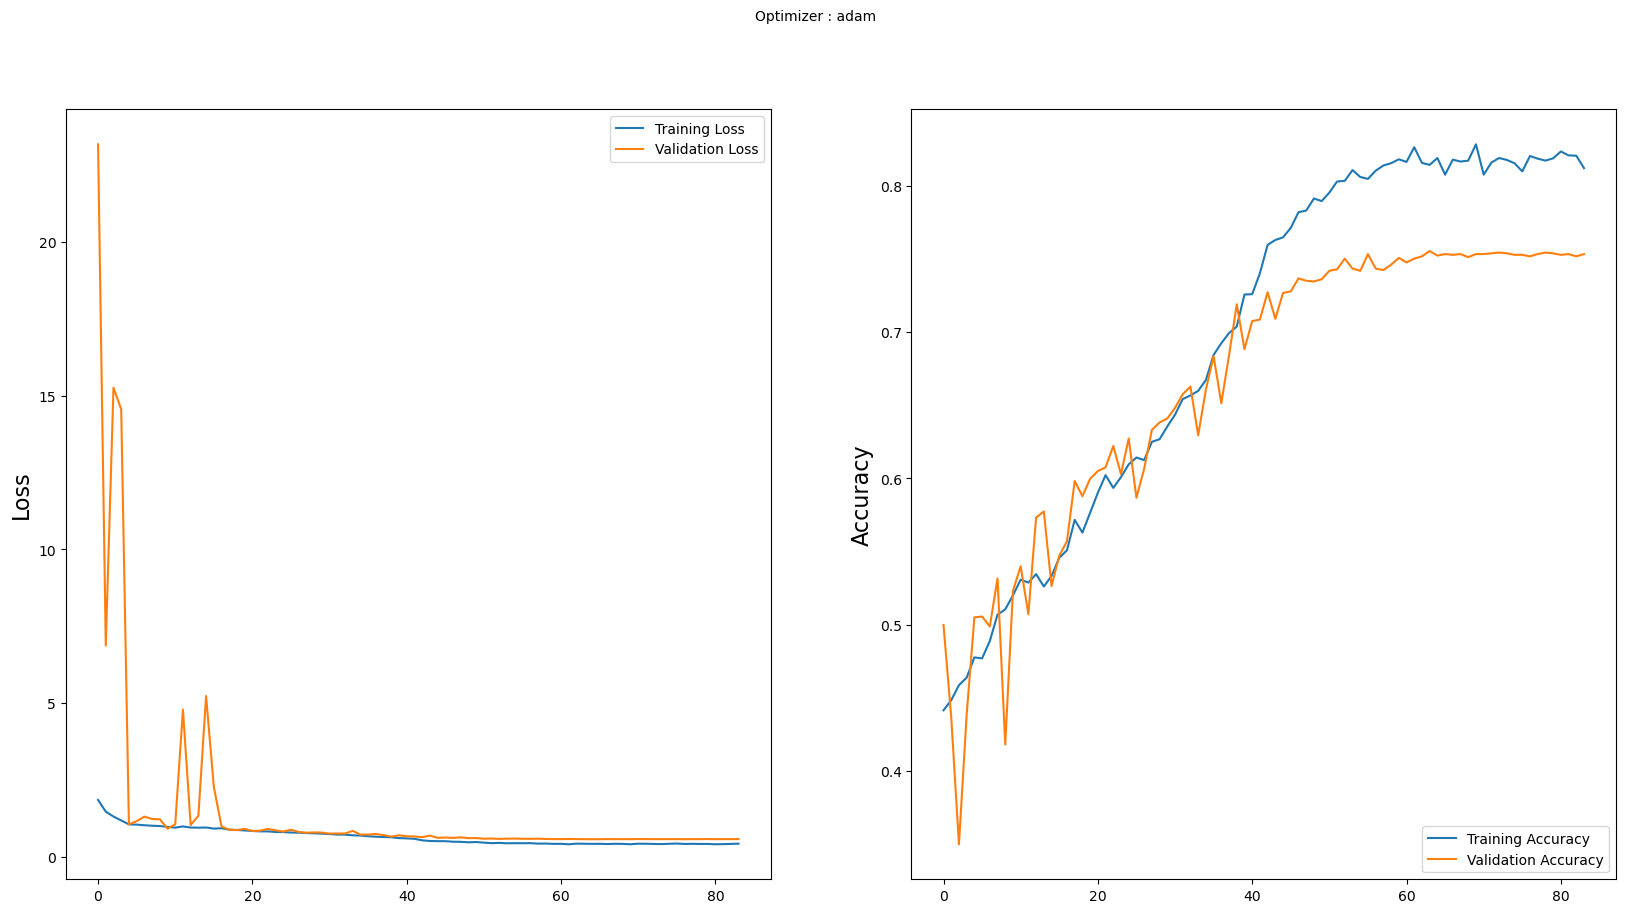

In [45]:
import matplotlib.pyplot as plt

x=hist9
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# DenseNet121

In [46]:
base_model = DenseNet121(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model10 = Model(inputs = base_model.inputs, outputs = prediction1)
model10.summary()
model10.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_9"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 134, 134, 3)  0          ['input_10[0][0]']               
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d[0][0]']         
                                                                                                  
 conv1/bn (BatchNormalization)  (None, 64, 64, 64)   256         ['conv1/conv[0][0]']       

                                                                                                  
 conv2_block4_1_bn (BatchNormal  (None, 32, 32, 128)  512        ['conv2_block4_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block4_1_relu (Activatio  (None, 32, 32, 128)  0          ['conv2_block4_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block4_2_conv (Conv2D)   (None, 32, 32, 32)   36864       ['conv2_block4_1_relu[0][0]']    
                                                                                                  
 conv2_block4_concat (Concatena  (None, 32, 32, 192)  0          ['conv2_block3_concat[0][0]',    
 te)      

 conv3_block2_1_conv (Conv2D)   (None, 16, 16, 128)  20480       ['conv3_block2_0_relu[0][0]']    
                                                                                                  
 conv3_block2_1_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_1_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block2_1_relu[0][0]']    
                                                                                                  
 conv3_blo

                                                                                                  
 conv3_block6_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block6_1_relu[0][0]']    
                                                                                                  
 conv3_block6_concat (Concatena  (None, 16, 16, 320)  0          ['conv3_block5_concat[0][0]',    
 te)                                                              'conv3_block6_2_conv[0][0]']    
                                                                                                  
 conv3_block7_0_bn (BatchNormal  (None, 16, 16, 320)  1280       ['conv3_block6_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block7_0_relu (Activatio  (None, 16, 16, 320)  0          ['conv3_block7_0_bn[0][0]']      
 n)       

 lization)                                                                                        
                                                                                                  
 conv3_block11_0_relu (Activati  (None, 16, 16, 448)  0          ['conv3_block11_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv3_block11_1_conv (Conv2D)  (None, 16, 16, 128)  57344       ['conv3_block11_0_relu[0][0]']   
                                                                                                  
 conv3_block11_1_bn (BatchNorma  (None, 16, 16, 128)  512        ['conv3_block11_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv3_blo

...

 lization)                                                                                        
                                                                                                  
 conv4_block20_1_relu (Activati  (None, 8, 8, 128)   0           ['conv4_block20_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv4_block20_2_conv (Conv2D)  (None, 8, 8, 32)     36864       ['conv4_block20_1_relu[0][0]']   
                                                                                                  
 conv4_block20_concat (Concaten  (None, 8, 8, 896)   0           ['conv4_block19_concat[0][0]',   
 ate)                                                             'conv4_block20_2_conv[0][0]']   
                                                                                                  
 conv4_blo

 conv4_block24_concat (Concaten  (None, 8, 8, 1024)  0           ['conv4_block23_concat[0][0]',   
 ate)                                                             'conv4_block24_2_conv[0][0]']   
                                                                                                  
 pool4_bn (BatchNormalization)  (None, 8, 8, 1024)   4096        ['conv4_block24_concat[0][0]']   
                                                                                                  
 pool4_relu (Activation)        (None, 8, 8, 1024)   0           ['pool4_bn[0][0]']               
                                                                                                  
 pool4_conv (Conv2D)            (None, 8, 8, 512)    524288      ['pool4_relu[0][0]']             
                                                                                                  
 pool4_pool (AveragePooling2D)  (None, 4, 4, 512)    0           ['pool4_conv[0][0]']             
          

                                                                                                  
 conv5_block4_concat (Concatena  (None, 4, 4, 640)   0           ['conv5_block3_concat[0][0]',    
 te)                                                              'conv5_block4_2_conv[0][0]']    
                                                                                                  
 conv5_block5_0_bn (BatchNormal  (None, 4, 4, 640)   2560        ['conv5_block4_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block5_0_relu (Activatio  (None, 4, 4, 640)   0           ['conv5_block5_0_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_blo

 conv5_block9_0_relu (Activatio  (None, 4, 4, 768)   0           ['conv5_block9_0_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv5_block9_1_conv (Conv2D)   (None, 4, 4, 128)    98304       ['conv5_block9_0_relu[0][0]']    
                                                                                                  
 conv5_block9_1_bn (BatchNormal  (None, 4, 4, 128)   512         ['conv5_block9_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv5_block9_1_relu (Activatio  (None, 4, 4, 128)   0           ['conv5_block9_1_bn[0][0]']      
 n)                                                                                               
          

                                                                                                  
 conv5_block13_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block13_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block13_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block13_1_relu[0][0]']   
                                                                                                  
 conv5_block13_concat (Concaten  (None, 4, 4, 928)   0           ['conv5_block12_concat[0][0]',   
 ate)                                                             'conv5_block13_2_conv[0][0]']   
                                                                                                  
 conv5_block14_0_bn (BatchNorma  (None, 4, 4, 928)   3712        ['conv5_block13_concat[0][0]']   
 lization)

In [47]:
hist10 = model10.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 162s 68ms/step - loss: 2.9467 - accuracy: 0.4296 - f1_m: 0.4104 - precision_m: 0.4313 - recall_m: 0.4000 - val_loss: 82.0137 - val_accuracy: 0.3498 - val_f1_m: 0.3502 - val_precision_m: 0.3502 - val_recall_m: 0.3502 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 150s 67ms/step - loss: 1.3265 - accuracy: 0.4436 - f1_m: 0.3839 - precision_m: 0.4335 - recall_m: 0.3592 - val_loss: 220.9086 - val_accuracy: 0.3259 - val_f1_m: 0.3262 - val_precision_m: 0.3262 - val_recall_m: 0.3262 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 150s 67ms/step - loss: 1.0178 - accuracy: 0.4994 - f1_m: 0.3691 - precision_m: 0.4917 - recall_m: 0.3078 - val_loss: 1.6101 - val_accuracy: 0.3769 - val_f1_m: 0.3439 - val_precision_m: 0.3710 - val_recall_m: 0.3304 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 150s 67ms/step - loss: 0.9800 - accuracy: 0.5256 - f1_m: 0.4000 - precision_m: 0.5295

Epoch 25/100
2240/2240 [==============================] - 150s 67ms/step - loss: 0.7800 - accuracy: 0.6269 - f1_m: 0.5561 - precision_m: 0.6652 - recall_m: 0.5016 - val_loss: 42.0614 - val_accuracy: 0.5528 - val_f1_m: 0.5028 - val_precision_m: 0.5531 - val_recall_m: 0.4776 - lr: 7.2900e-07
Epoch 26/100
2240/2240 [==============================] - 149s 67ms/step - loss: 0.7834 - accuracy: 0.6238 - f1_m: 0.5478 - precision_m: 0.6518 - recall_m: 0.4958 - val_loss: 43.2139 - val_accuracy: 0.5544 - val_f1_m: 0.5014 - val_precision_m: 0.5489 - val_recall_m: 0.4776 - lr: 7.2900e-07
Epoch 27/100
2240/2240 [==============================] - ETA: 0s - loss: 0.7879 - accuracy: 0.6301 - f1_m: 0.5438 - precision_m: 0.6482 - recall_m: 0.4915
Epoch 27: ReduceLROnPlateau reducing learning rate to 2.1870000637136398e-07.
2240/2240 [==============================] - 150s 67ms/step - loss: 0.7879 - accuracy: 0.6301 - f1_m: 0.5438 - precision_m: 0.6482 - recall_m: 0.4915 - val_loss: 53.7806 - val_accuracy

In [44]:
dl_acc = hist10.history["val_accuracy"][31]
dl_prec = hist10.history["val_precision_m"][31]
dl_rec = hist10.history["val_recall_m"][31]
dl_f1 = hist10.history["val_f1_m"][31]

storeResults('DenseNet121',dl_acc,dl_prec,dl_rec,dl_f1)

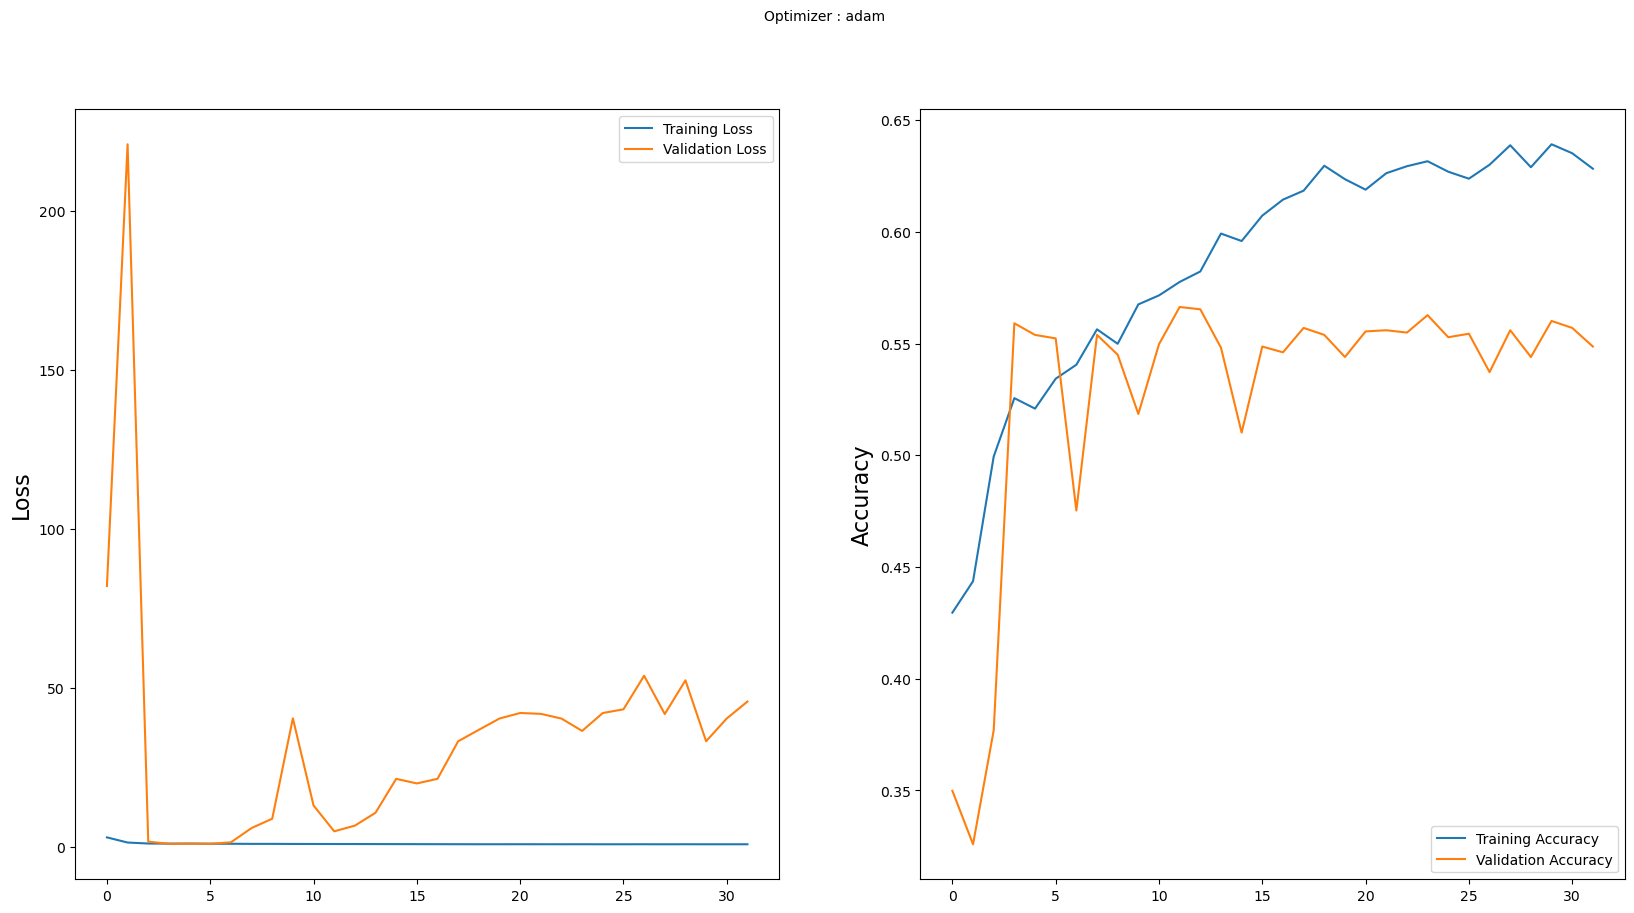

In [48]:
import matplotlib.pyplot as plt

x=hist10
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# DenseNet169

In [49]:
base_model = DenseNet169(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model11 = Model(inputs = base_model.inputs, outputs = prediction1)
model11.summary()
model11.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_10"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_11 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d_2 (ZeroPadding2  (None, 134, 134, 3)  0          ['input_11[0][0]']               
 D)                                                                                               
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d_2[0][0]']       
                                                                                           

 conv2_block4_1_conv (Conv2D)   (None, 32, 32, 128)  20480       ['conv2_block4_0_relu[0][0]']    
                                                                                                  
 conv2_block4_1_bn (BatchNormal  (None, 32, 32, 128)  512        ['conv2_block4_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block4_1_relu (Activatio  (None, 32, 32, 128)  0          ['conv2_block4_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block4_2_conv (Conv2D)   (None, 32, 32, 32)   36864       ['conv2_block4_1_relu[0][0]']    
                                                                                                  
 conv2_blo

                                                                                                  
 conv3_block2_1_conv (Conv2D)   (None, 16, 16, 128)  20480       ['conv3_block2_0_relu[0][0]']    
                                                                                                  
 conv3_block2_1_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_1_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block2_1_relu[0][0]']    
          

 n)                                                                                               
                                                                                                  
 conv3_block6_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block6_1_relu[0][0]']    
                                                                                                  
 conv3_block6_concat (Concatena  (None, 16, 16, 320)  0          ['conv3_block5_concat[0][0]',    
 te)                                                              'conv3_block6_2_conv[0][0]']    
                                                                                                  
 conv3_block7_0_bn (BatchNormal  (None, 16, 16, 320)  1280       ['conv3_block6_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_blo

 conv3_block11_0_bn (BatchNorma  (None, 16, 16, 448)  1792       ['conv3_block10_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv3_block11_0_relu (Activati  (None, 16, 16, 448)  0          ['conv3_block11_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv3_block11_1_conv (Conv2D)  (None, 16, 16, 128)  57344       ['conv3_block11_0_relu[0][0]']   
                                                                                                  
 conv3_block11_1_bn (BatchNorma  (None, 16, 16, 128)  512        ['conv3_block11_1_conv[0][0]']   
 lization)                                                                                        
          

...

 on)                                                                                              
                                                                                                  
 conv5_block14_1_conv (Conv2D)  (None, 4, 4, 128)    135168      ['conv5_block14_0_relu[0][0]']   
                                                                                                  
 conv5_block14_1_bn (BatchNorma  (None, 4, 4, 128)   512         ['conv5_block14_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block14_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block14_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_blo

 conv5_block18_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block18_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block18_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block18_1_relu[0][0]']   
                                                                                                  
 conv5_block18_concat (Concaten  (None, 4, 4, 1216)  0           ['conv5_block17_concat[0][0]',   
 ate)                                                             'conv5_block18_2_conv[0][0]']   
                                                                                                  
 conv5_block19_0_bn (BatchNorma  (None, 4, 4, 1216)  4864        ['conv5_block18_concat[0][0]']   
 lization)                                                                                        
          

                                                                                                  
 conv5_block23_0_bn (BatchNorma  (None, 4, 4, 1344)  5376        ['conv5_block22_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block23_0_relu (Activati  (None, 4, 4, 1344)  0           ['conv5_block23_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block23_1_conv (Conv2D)  (None, 4, 4, 128)    172032      ['conv5_block23_0_relu[0][0]']   
                                                                                                  
 conv5_block23_1_bn (BatchNorma  (None, 4, 4, 128)   512         ['conv5_block23_1_conv[0][0]']   
 lization)

 conv5_block27_1_conv (Conv2D)  (None, 4, 4, 128)    188416      ['conv5_block27_0_relu[0][0]']   
                                                                                                  
 conv5_block27_1_bn (BatchNorma  (None, 4, 4, 128)   512         ['conv5_block27_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block27_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block27_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block27_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block27_1_relu[0][0]']   
                                                                                                  
 conv5_blo

                                                                                                  
 conv5_block31_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block31_1_relu[0][0]']   
                                                                                                  
 conv5_block31_concat (Concaten  (None, 4, 4, 1632)  0           ['conv5_block30_concat[0][0]',   
 ate)                                                             'conv5_block31_2_conv[0][0]']   
                                                                                                  
 conv5_block32_0_bn (BatchNorma  (None, 4, 4, 1632)  6528        ['conv5_block31_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block32_0_relu (Activati  (None, 4, 4, 1632)  0           ['conv5_block32_0_bn[0][0]']     
 on)      

In [50]:
hist11 = model11.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 220s 92ms/step - loss: 3.1227 - accuracy: 0.4101 - f1_m: 0.3938 - precision_m: 0.4125 - recall_m: 0.3844 - val_loss: 43.6691 - val_accuracy: 0.0115 - val_f1_m: 0.0114 - val_precision_m: 0.0114 - val_recall_m: 0.0114 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 204s 91ms/step - loss: 1.0923 - accuracy: 0.4758 - f1_m: 0.4038 - precision_m: 0.4868 - recall_m: 0.3623 - val_loss: 1.0890 - val_accuracy: 0.4534 - val_f1_m: 0.2237 - val_precision_m: 0.3070 - val_recall_m: 0.1821 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 203s 91ms/step - loss: 1.0576 - accuracy: 0.4863 - f1_m: 0.3694 - precision_m: 0.4699 - recall_m: 0.3192 - val_loss: 1.7976 - val_accuracy: 0.5232 - val_f1_m: 0.4360 - val_precision_m: 0.5120 - val_recall_m: 0.3980 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 203s 91ms/step - loss: 1.0134 - accuracy: 0.5032 - f1_m: 0.3926 - precision_m: 0.5208 -

Epoch 54/100
2240/2240 [==============================] - ETA: 0s - loss: 0.7803 - accuracy: 0.6251 - f1_m: 0.5431 - precision_m: 0.6516 - recall_m: 0.4888
Epoch 54: ReduceLROnPlateau reducing learning rate to 7.289999985005124e-07.
2240/2240 [==============================] - 202s 90ms/step - loss: 0.7803 - accuracy: 0.6251 - f1_m: 0.5431 - precision_m: 0.6516 - recall_m: 0.4888 - val_loss: 1.6591 - val_accuracy: 0.6231 - val_f1_m: 0.5189 - val_precision_m: 0.6233 - val_recall_m: 0.4667 - lr: 2.4300e-06
Epoch 55/100
2240/2240 [==============================] - 203s 90ms/step - loss: 0.7729 - accuracy: 0.6292 - f1_m: 0.5556 - precision_m: 0.6717 - recall_m: 0.4975 - val_loss: 1.4505 - val_accuracy: 0.6231 - val_f1_m: 0.5184 - val_precision_m: 0.6270 - val_recall_m: 0.4641 - lr: 7.2900e-07
Epoch 56/100
2240/2240 [==============================] - 203s 90ms/step - loss: 0.7738 - accuracy: 0.6372 - f1_m: 0.5531 - precision_m: 0.6629 - recall_m: 0.4982 - val_loss: 1.6313 - val_accuracy: 0.

2240/2240 [==============================] - 208s 93ms/step - loss: 0.7703 - accuracy: 0.6361 - f1_m: 0.5467 - precision_m: 0.6567 - recall_m: 0.4917 - val_loss: 1.6217 - val_accuracy: 0.6216 - val_f1_m: 0.5222 - val_precision_m: 0.6301 - val_recall_m: 0.4683 - lr: 1.0000e-07
Epoch 81/100
2240/2240 [==============================] - 208s 93ms/step - loss: 0.7717 - accuracy: 0.6394 - f1_m: 0.5559 - precision_m: 0.6717 - recall_m: 0.4980 - val_loss: 1.5304 - val_accuracy: 0.6184 - val_f1_m: 0.5180 - val_precision_m: 0.6259 - val_recall_m: 0.4641 - lr: 1.0000e-07
Epoch 82/100
2240/2240 [==============================] - 208s 93ms/step - loss: 0.7804 - accuracy: 0.6260 - f1_m: 0.5462 - precision_m: 0.6569 - recall_m: 0.4908 - val_loss: 1.6052 - val_accuracy: 0.6226 - val_f1_m: 0.5199 - val_precision_m: 0.6264 - val_recall_m: 0.4667 - lr: 1.0000e-07
Epoch 82: early stopping


In [45]:
dl_acc = hist11.history["val_accuracy"][81]
dl_prec = hist11.history["val_precision_m"][81]
dl_rec = hist11.history["val_recall_m"][81]
dl_f1 = hist11.history["val_f1_m"][81]

storeResults('DenseNet169',dl_acc,dl_prec,dl_rec,dl_f1)

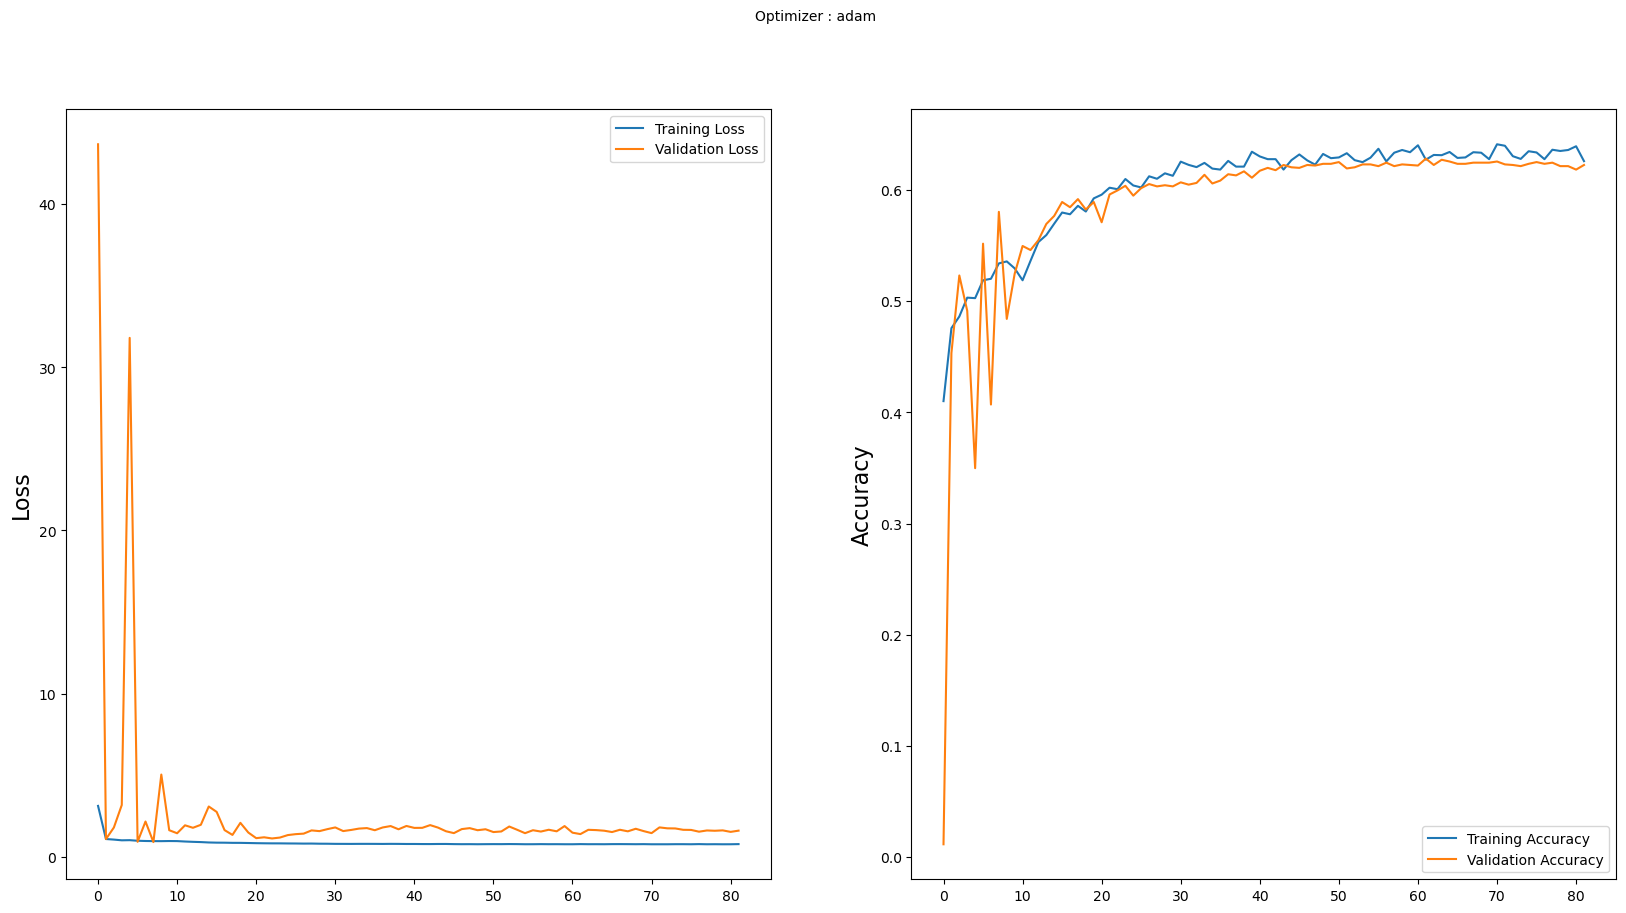

In [51]:
import matplotlib.pyplot as plt

x=hist11
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# DenseNet201

In [52]:
base_model = DenseNet201(input_shape = IMAGE_SIZE + [3], weights='imagenet', include_top=False)

x1= Flatten()(base_model.output)
prediction1 = Dense(4, activation='softmax')(x1)
model12 = Model(inputs = base_model.inputs, outputs = prediction1)
model12.summary()
model12.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])

Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d_4 (ZeroPadding2  (None, 134, 134, 3)  0          ['input_12[0][0]']               
 D)                                                                                               
                                                                                                  
 conv1/conv (Conv2D)            (None, 64, 64, 64)   9408        ['zero_padding2d_4[0][0]']       
                                                                                           

 conv2_block4_1_conv (Conv2D)   (None, 32, 32, 128)  20480       ['conv2_block4_0_relu[0][0]']    
                                                                                                  
 conv2_block4_1_bn (BatchNormal  (None, 32, 32, 128)  512        ['conv2_block4_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv2_block4_1_relu (Activatio  (None, 32, 32, 128)  0          ['conv2_block4_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv2_block4_2_conv (Conv2D)   (None, 32, 32, 32)   36864       ['conv2_block4_1_relu[0][0]']    
                                                                                                  
 conv2_blo

                                                                                                  
 conv3_block2_1_conv (Conv2D)   (None, 16, 16, 128)  20480       ['conv3_block2_0_relu[0][0]']    
                                                                                                  
 conv3_block2_1_bn (BatchNormal  (None, 16, 16, 128)  512        ['conv3_block2_1_conv[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_block2_1_relu (Activatio  (None, 16, 16, 128)  0          ['conv3_block2_1_bn[0][0]']      
 n)                                                                                               
                                                                                                  
 conv3_block2_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block2_1_relu[0][0]']    
          

 n)                                                                                               
                                                                                                  
 conv3_block6_2_conv (Conv2D)   (None, 16, 16, 32)   36864       ['conv3_block6_1_relu[0][0]']    
                                                                                                  
 conv3_block6_concat (Concatena  (None, 16, 16, 320)  0          ['conv3_block5_concat[0][0]',    
 te)                                                              'conv3_block6_2_conv[0][0]']    
                                                                                                  
 conv3_block7_0_bn (BatchNormal  (None, 16, 16, 320)  1280       ['conv3_block6_concat[0][0]']    
 ization)                                                                                         
                                                                                                  
 conv3_blo

 conv3_block11_0_bn (BatchNorma  (None, 16, 16, 448)  1792       ['conv3_block10_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv3_block11_0_relu (Activati  (None, 16, 16, 448)  0          ['conv3_block11_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv3_block11_1_conv (Conv2D)  (None, 16, 16, 128)  57344       ['conv3_block11_0_relu[0][0]']   
                                                                                                  
 conv3_block11_1_bn (BatchNorma  (None, 16, 16, 128)  512        ['conv3_block11_1_conv[0][0]']   
 lization)                                                                                        
          

...

                                                                                                  
 conv5_block15_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block15_1_relu[0][0]']   
                                                                                                  
 conv5_block15_concat (Concaten  (None, 4, 4, 1376)  0           ['conv5_block14_concat[0][0]',   
 ate)                                                             'conv5_block15_2_conv[0][0]']   
                                                                                                  
 conv5_block16_0_bn (BatchNorma  (None, 4, 4, 1376)  5504        ['conv5_block15_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block16_0_relu (Activati  (None, 4, 4, 1376)  0           ['conv5_block16_0_bn[0][0]']     
 on)      

 lization)                                                                                        
                                                                                                  
 conv5_block20_0_relu (Activati  (None, 4, 4, 1504)  0           ['conv5_block20_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block20_1_conv (Conv2D)  (None, 4, 4, 128)    192512      ['conv5_block20_0_relu[0][0]']   
                                                                                                  
 conv5_block20_1_bn (BatchNorma  (None, 4, 4, 128)   512         ['conv5_block20_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_blo

 conv5_block24_1_bn (BatchNorma  (None, 4, 4, 128)   512         ['conv5_block24_1_conv[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block24_1_relu (Activati  (None, 4, 4, 128)   0           ['conv5_block24_1_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_block24_2_conv (Conv2D)  (None, 4, 4, 32)     36864       ['conv5_block24_1_relu[0][0]']   
                                                                                                  
 conv5_block24_concat (Concaten  (None, 4, 4, 1664)  0           ['conv5_block23_concat[0][0]',   
 ate)                                                             'conv5_block24_2_conv[0][0]']   
          

                                                                                                  
 conv5_block28_concat (Concaten  (None, 4, 4, 1792)  0           ['conv5_block27_concat[0][0]',   
 ate)                                                             'conv5_block28_2_conv[0][0]']   
                                                                                                  
 conv5_block29_0_bn (BatchNorma  (None, 4, 4, 1792)  7168        ['conv5_block28_concat[0][0]']   
 lization)                                                                                        
                                                                                                  
 conv5_block29_0_relu (Activati  (None, 4, 4, 1792)  0           ['conv5_block29_0_bn[0][0]']     
 on)                                                                                              
                                                                                                  
 conv5_blo

                                                                                                  
 flatten_10 (Flatten)           (None, 30720)        0           ['relu[0][0]']                   
                                                                                                  
 dense_11 (Dense)               (None, 4)            122884      ['flatten_10[0][0]']             
                                                                                                  
Total params: 18,444,868
Trainable params: 18,215,812
Non-trainable params: 229,056
__________________________________________________________________________________________________


In [53]:
hist12 = model12.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 265s 111ms/step - loss: 2.6626 - accuracy: 0.4316 - f1_m: 0.4141 - precision_m: 0.4353 - recall_m: 0.4036 - val_loss: 5067.0220 - val_accuracy: 0.1499 - val_f1_m: 0.1459 - val_precision_m: 0.1472 - val_recall_m: 0.1452 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 245s 109ms/step - loss: 1.1221 - accuracy: 0.4954 - f1_m: 0.4310 - precision_m: 0.5121 - recall_m: 0.3904 - val_loss: 0.9263 - val_accuracy: 0.5575 - val_f1_m: 0.3793 - val_precision_m: 0.5104 - val_recall_m: 0.3137 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 245s 109ms/step - loss: 1.0295 - accuracy: 0.5088 - f1_m: 0.3854 - precision_m: 0.5134 - recall_m: 0.3214 - val_loss: 3.0136 - val_accuracy: 0.5544 - val_f1_m: 0.3595 - val_precision_m: 0.4729 - val_recall_m: 0.3028 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 245s 110ms/step - loss: 1.0272 - accuracy: 0.5032 - f1_m: 0.3824 - precision_m: 0.

In [46]:
dl_acc = hist12.history["val_accuracy"][21]
dl_prec = hist12.history["val_precision_m"][21]
dl_rec = hist12.history["val_recall_m"][21]
dl_f1 = hist12.history["val_f1_m"][21]

storeResults('DenseNet201',dl_acc,dl_prec,dl_rec,dl_f1)

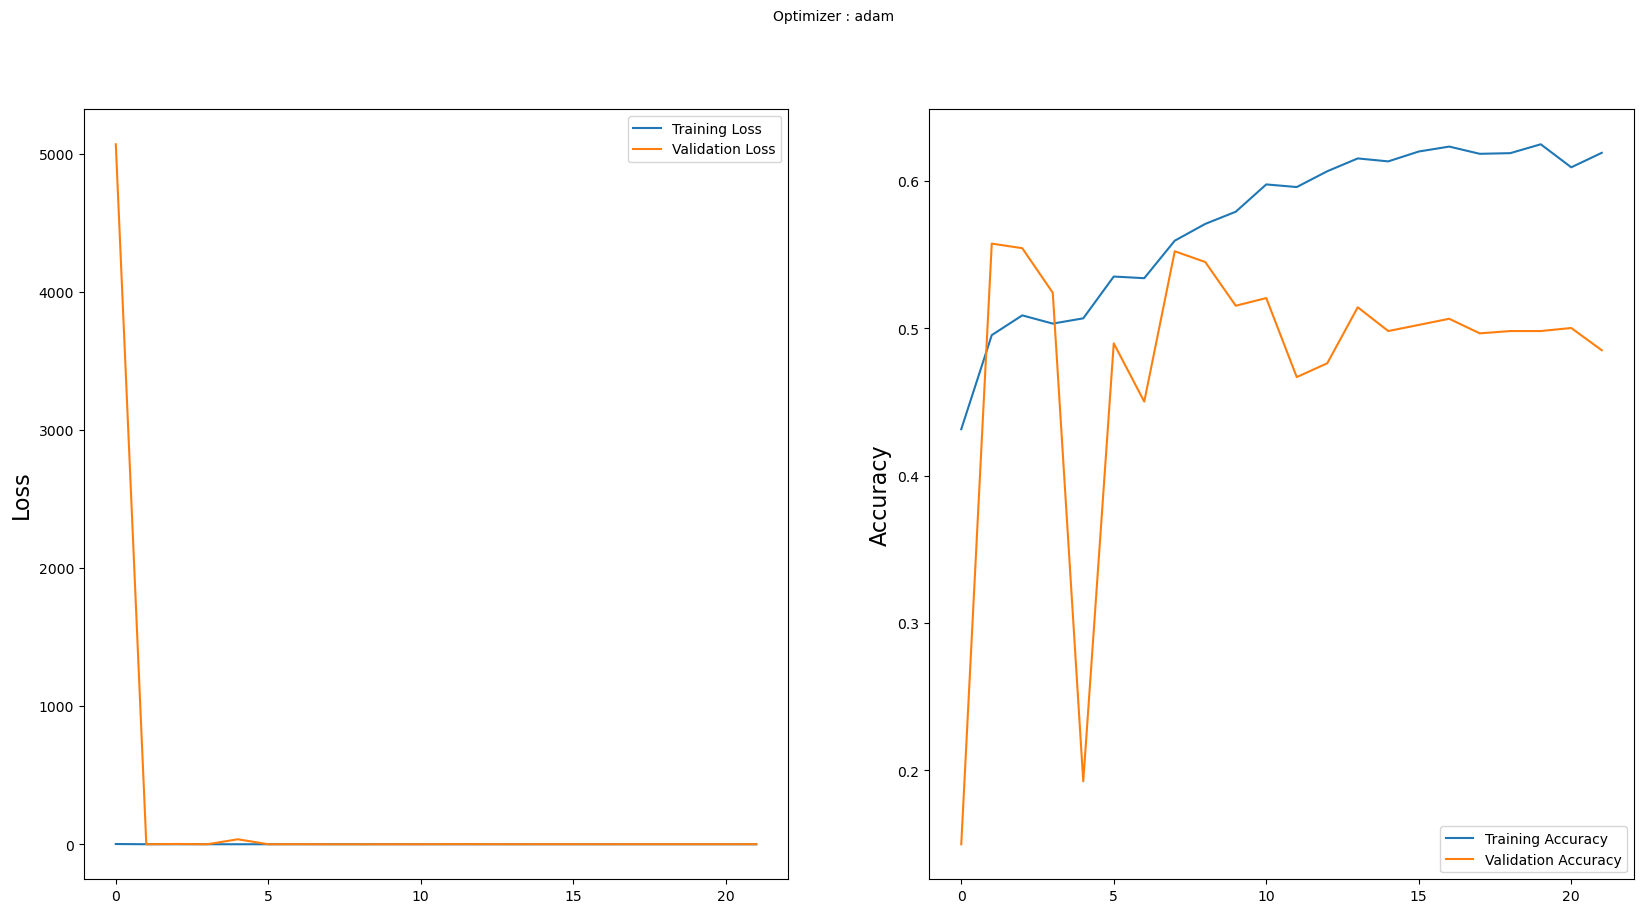

In [54]:
import matplotlib.pyplot as plt

x=hist12
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# CNN

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [56]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPool2D(strides=2))
model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(MaxPool2D(strides=2))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [57]:
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=["accuracy",f1_m,precision_m, recall_m])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_301 (Conv2D)         (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_11 (MaxPoolin  (None, 64, 64, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_302 (Conv2D)         (None, 60, 60, 48)        38448     
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 30, 30, 48)       0         
 g2D)                                                            
                                                                 
 flatten_11 (Flatten)        (None, 43200)             0         
                                                                 
 dense_12 (Dense)            (None, 256)               1

In [58]:
hist13 = model.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set))

Epoch 1/100
2240/2240 [==============================] - 23s 10ms/step - loss: 1.0340 - accuracy: 0.5017 - f1_m: 0.2968 - precision_m: 0.3690 - recall_m: 0.2607 - val_loss: 0.9281 - val_accuracy: 0.5679 - val_f1_m: 0.4133 - val_precision_m: 0.5260 - val_recall_m: 0.3569
Epoch 2/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.9224 - accuracy: 0.5570 - f1_m: 0.3978 - precision_m: 0.5067 - recall_m: 0.3433 - val_loss: 0.8667 - val_accuracy: 0.5955 - val_f1_m: 0.4031 - val_precision_m: 0.5255 - val_recall_m: 0.3418
Epoch 3/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.8690 - accuracy: 0.5912 - f1_m: 0.4660 - precision_m: 0.5757 - recall_m: 0.4112 - val_loss: 0.8468 - val_accuracy: 0.5914 - val_f1_m: 0.4802 - val_precision_m: 0.5812 - val_recall_m: 0.4298
Epoch 4/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.8123 - accuracy: 0.6196 - f1_m: 0.5394 - precision_m: 0.6317 - recall_m: 0.4933 - val_loss: 0.8342 - val_a

2240/2240 [==============================] - 22s 10ms/step - loss: 0.0741 - accuracy: 0.9779 - f1_m: 0.9776 - precision_m: 0.9788 - recall_m: 0.9770 - val_loss: 0.1907 - val_accuracy: 0.9542 - val_f1_m: 0.9542 - val_precision_m: 0.9553 - val_recall_m: 0.9537
Epoch 62/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0918 - accuracy: 0.9743 - f1_m: 0.9742 - precision_m: 0.9752 - recall_m: 0.9737 - val_loss: 0.2255 - val_accuracy: 0.9516 - val_f1_m: 0.9521 - val_precision_m: 0.9532 - val_recall_m: 0.9516
Epoch 63/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0834 - accuracy: 0.9763 - f1_m: 0.9764 - precision_m: 0.9770 - recall_m: 0.9761 - val_loss: 0.2372 - val_accuracy: 0.9464 - val_f1_m: 0.9464 - val_precision_m: 0.9475 - val_recall_m: 0.9459
Epoch 64/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0713 - accuracy: 0.9786 - f1_m: 0.9786 - precision_m: 0.9797 - recall_m: 0.9781 - val_loss: 0.1904 - val_accuracy: 

In [47]:
dl_acc = hist13.history["val_accuracy"][99]
dl_prec = hist13.history["val_precision_m"][99]
dl_rec = hist13.history["val_recall_m"][99]
dl_f1 = hist13.history["val_f1_m"][99]

storeResults('CNN - Adam Optimizer',dl_acc,dl_prec,dl_rec,dl_f1)

In [61]:
model.save('cnn1.h5')

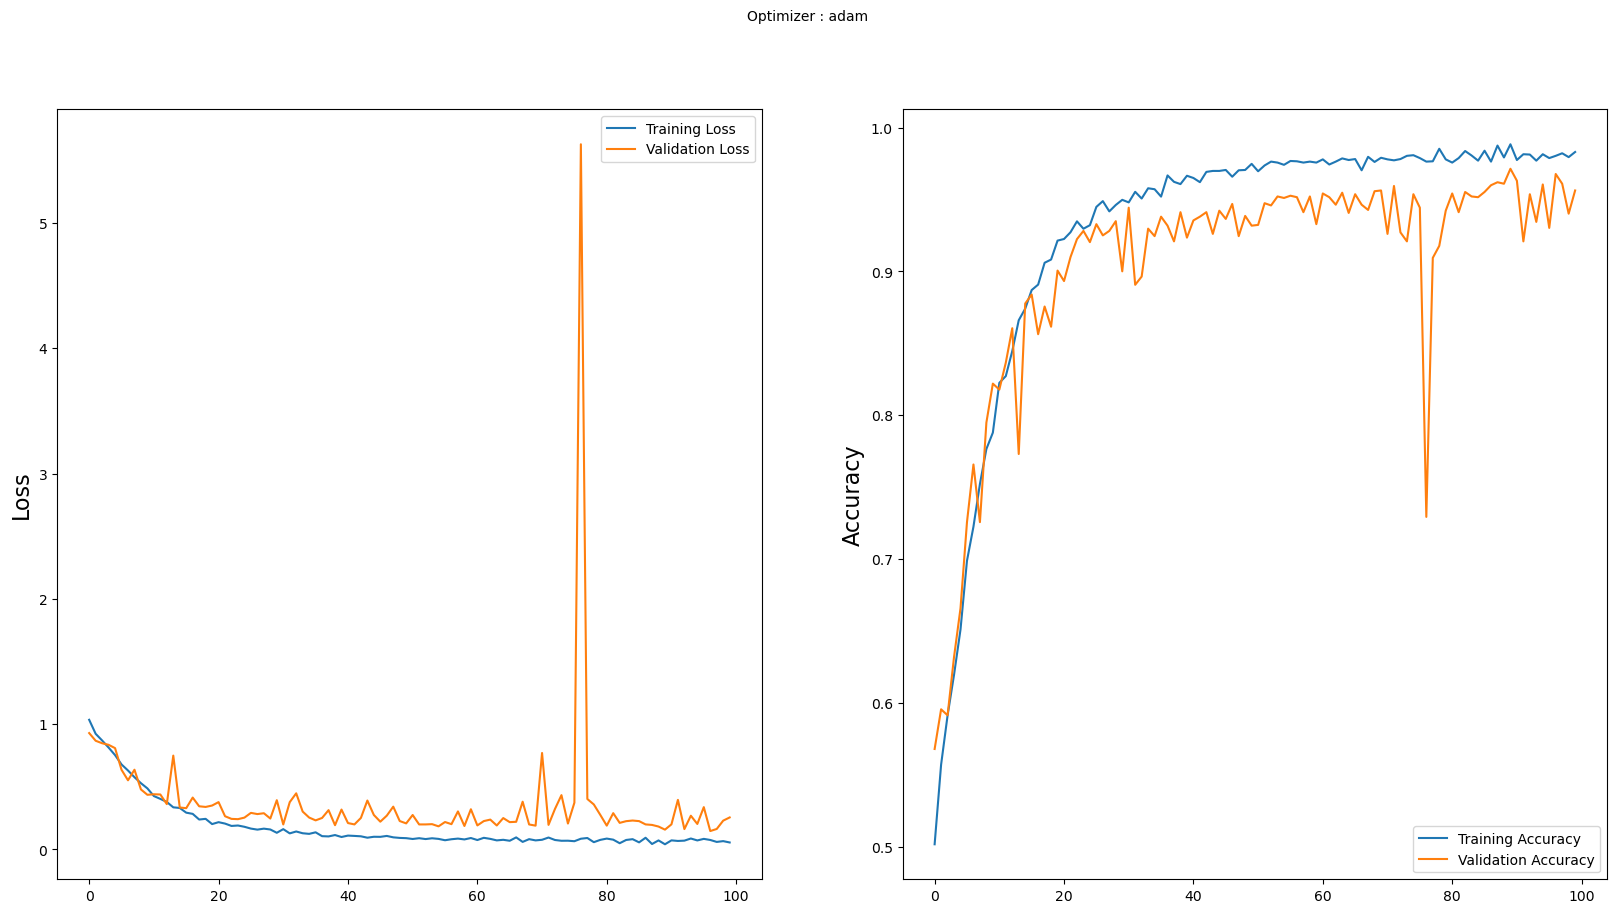

In [59]:
import matplotlib.pyplot as plt

x=hist13
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# CNN - SGD

In [12]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPool2D(strides=2))
model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(MaxPool2D(strides=2))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [13]:
model.compile(loss = 'categorical_crossentropy', optimizer='sgd', metrics=["accuracy",f1_m,precision_m, recall_m])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 60, 60, 48)        38448     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 48)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 43200)             0         
                                                                 
 dense (Dense)               (None, 256)               1

In [15]:
hist14 = model.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.4672 - accuracy: 0.7997 - f1_m: 0.7907 - precision_m: 0.8136 - recall_m: 0.7792 - val_loss: 0.3459 - val_accuracy: 0.8594 - val_f1_m: 0.8540 - val_precision_m: 0.8689 - val_recall_m: 0.8465 - lr: 0.0100
Epoch 2/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.4054 - accuracy: 0.8321 - f1_m: 0.8263 - precision_m: 0.8444 - recall_m: 0.8172 - val_loss: 0.3136 - val_accuracy: 0.8730 - val_f1_m: 0.8677 - val_precision_m: 0.8809 - val_recall_m: 0.8611 - lr: 0.0100
Epoch 3/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.3353 - accuracy: 0.8629 - f1_m: 0.8608 - precision_m: 0.8748 - recall_m: 0.8538 - val_loss: 0.2761 - val_accuracy: 0.8881 - val_f1_m: 0.8864 - val_precision_m: 0.8913 - val_recall_m: 0.8840 - lr: 0.0100
Epoch 4/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.3111 - accuracy: 0.8761 - f1_m: 0.8712 - precision_m: 0.8815 - reca

Epoch 28/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0082 - accuracy: 0.9964 - f1_m: 0.9964 - precision_m: 0.9964 - recall_m: 0.9964 - val_loss: 0.0761 - val_accuracy: 0.9833 - val_f1_m: 0.9828 - val_precision_m: 0.9828 - val_recall_m: 0.9828 - lr: 2.7000e-04
Epoch 29/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0066 - accuracy: 0.9980 - f1_m: 0.9980 - precision_m: 0.9980 - recall_m: 0.9980 - val_loss: 0.0742 - val_accuracy: 0.9833 - val_f1_m: 0.9834 - val_precision_m: 0.9834 - val_recall_m: 0.9834 - lr: 2.7000e-04
Epoch 30/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0078 - accuracy: 0.9978 - f1_m: 0.9976 - precision_m: 0.9978 - recall_m: 0.9975 - val_loss: 0.0715 - val_accuracy: 0.9854 - val_f1_m: 0.9854 - val_precision_m: 0.9854 - val_recall_m: 0.9854 - lr: 2.7000e-04
Epoch 31/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0046 - accuracy: 0.9989 - f1_m: 0.9986 - precision_

In [48]:
dl_acc = hist14.history["val_accuracy"][49]
dl_prec = hist14.history["val_precision_m"][49]
dl_rec = hist14.history["val_recall_m"][49]
dl_f1 = hist14.history["val_f1_m"][49]

storeResults('CNN - SGD Optimizer',dl_acc,dl_prec,dl_rec,dl_f1)

In [16]:
model.save('cnn2.h5')

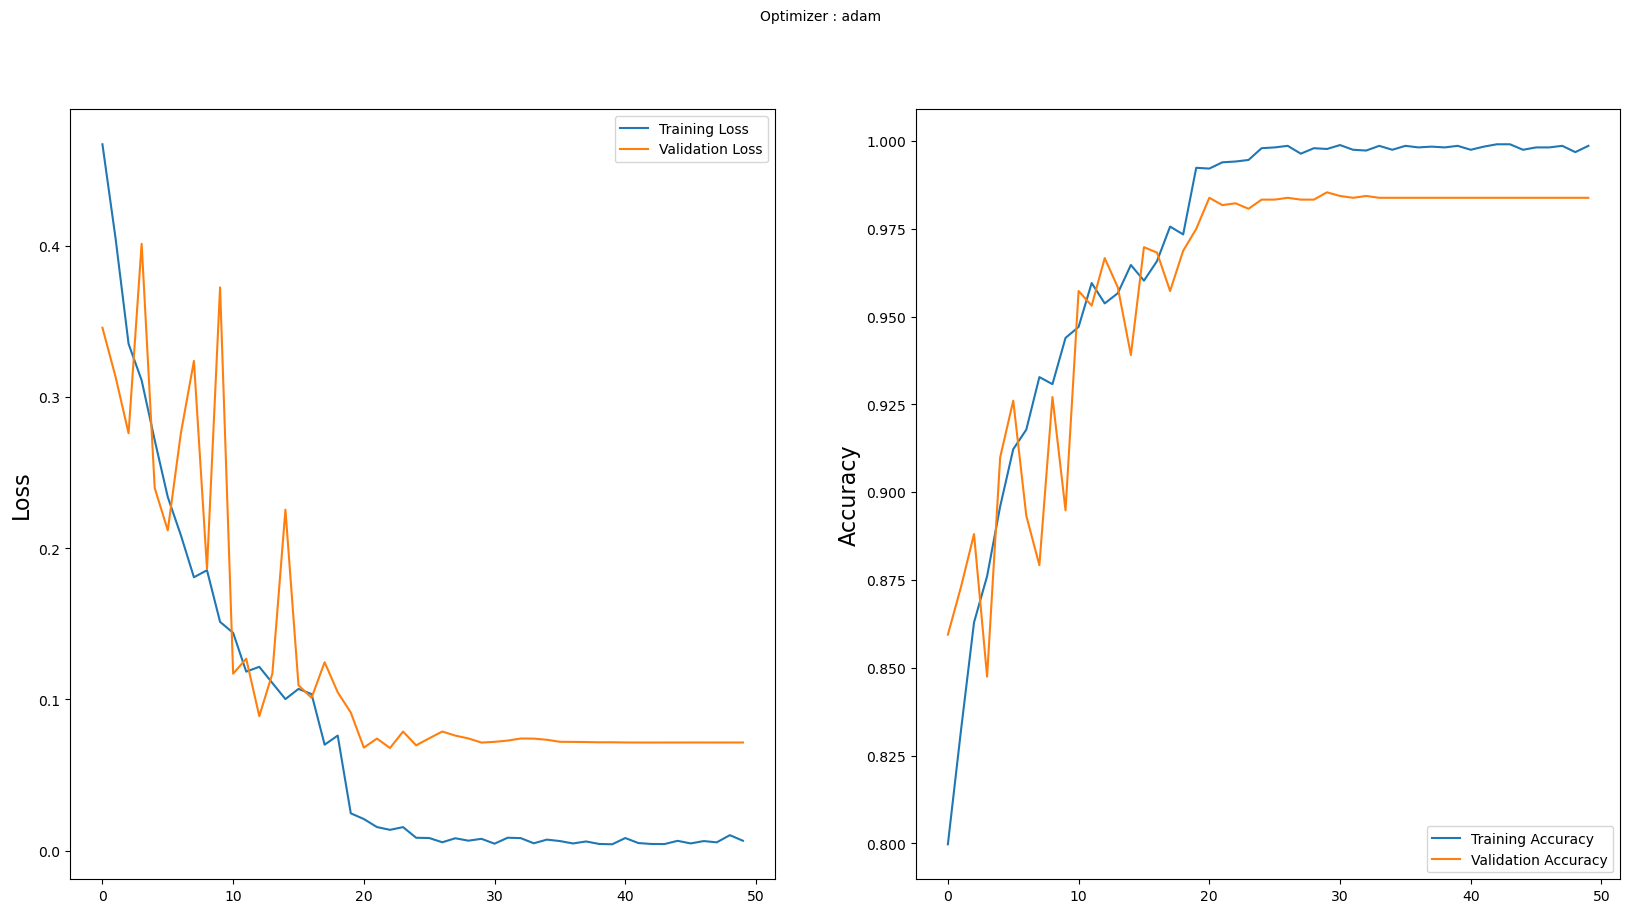

In [17]:
import matplotlib.pyplot as plt

x=hist14
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# CNN - Nadam

In [18]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='same', activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPool2D(strides=2))
model.add(Conv2D(filters=48, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(MaxPool2D(strides=2))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(84, activation='relu'))
model.add(Dense(4, activation='softmax'))

In [19]:
model.compile(loss = 'categorical_crossentropy', optimizer='nadam', metrics=["accuracy",f1_m,precision_m, recall_m])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 128, 128, 32)      2432      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 60, 60, 48)        38448     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 30, 30, 48)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 43200)             0         
                                                                 
 dense_3 (Dense)             (None, 256)              

In [20]:
hist15 = model.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 24s 10ms/step - loss: 0.9945 - accuracy: 0.5193 - f1_m: 0.3369 - precision_m: 0.4281 - recall_m: 0.2913 - val_loss: 0.8955 - val_accuracy: 0.5914 - val_f1_m: 0.5588 - val_precision_m: 0.6108 - val_recall_m: 0.5328 - lr: 0.0010
Epoch 2/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.8947 - accuracy: 0.5789 - f1_m: 0.4300 - precision_m: 0.5324 - recall_m: 0.3788 - val_loss: 0.7981 - val_accuracy: 0.6273 - val_f1_m: 0.5602 - val_precision_m: 0.6618 - val_recall_m: 0.5094 - lr: 0.0010
Epoch 3/100
2240/2240 [==============================] - 23s 10ms/step - loss: 0.7916 - accuracy: 0.6180 - f1_m: 0.5320 - precision_m: 0.6210 - recall_m: 0.4875 - val_loss: 0.6778 - val_accuracy: 0.6991 - val_f1_m: 0.6363 - val_precision_m: 0.7258 - val_recall_m: 0.5916 - lr: 0.0010
Epoch 4/100
2240/2240 [==============================] - 23s 10ms/step - loss: 0.7006 - accuracy: 0.6776 - f1_m: 0.6400 - precision_m: 0.7071 - reca

2240/2240 [==============================] - 24s 11ms/step - loss: 0.0241 - accuracy: 0.9924 - f1_m: 0.9920 - precision_m: 0.9926 - recall_m: 0.9917 - val_loss: 0.1436 - val_accuracy: 0.9662 - val_f1_m: 0.9662 - val_precision_m: 0.9672 - val_recall_m: 0.9657 - lr: 9.0000e-05
Epoch 29/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0225 - accuracy: 0.9922 - f1_m: 0.9922 - precision_m: 0.9922 - recall_m: 0.9922 - val_loss: 0.1540 - val_accuracy: 0.9630 - val_f1_m: 0.9634 - val_precision_m: 0.9641 - val_recall_m: 0.9631 - lr: 9.0000e-05
Epoch 30/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0232 - accuracy: 0.9920 - f1_m: 0.9920 - precision_m: 0.9922 - recall_m: 0.9920 - val_loss: 0.1498 - val_accuracy: 0.9682 - val_f1_m: 0.9679 - val_precision_m: 0.9683 - val_recall_m: 0.9677 - lr: 9.0000e-05
Epoch 31/100
2240/2240 [==============================] - 23s 10ms/step - loss: 0.0198 - accuracy: 0.9942 - f1_m: 0.9942 - precision_m: 0.9942 - r

Epoch 52/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0110 - accuracy: 0.9960 - f1_m: 0.9960 - precision_m: 0.9960 - recall_m: 0.9960 - val_loss: 0.1523 - val_accuracy: 0.9688 - val_f1_m: 0.9690 - val_precision_m: 0.9693 - val_recall_m: 0.9688 - lr: 1.0000e-07
Epoch 53/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0084 - accuracy: 0.9978 - f1_m: 0.9978 - precision_m: 0.9978 - recall_m: 0.9978 - val_loss: 0.1524 - val_accuracy: 0.9688 - val_f1_m: 0.9690 - val_precision_m: 0.9693 - val_recall_m: 0.9688 - lr: 1.0000e-07
Epoch 54/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0094 - accuracy: 0.9969 - f1_m: 0.9969 - precision_m: 0.9971 - recall_m: 0.9969 - val_loss: 0.1524 - val_accuracy: 0.9693 - val_f1_m: 0.9693 - val_precision_m: 0.9693 - val_recall_m: 0.9693 - lr: 1.0000e-07
Epoch 55/100
2240/2240 [==============================] - 22s 10ms/step - loss: 0.0088 - accuracy: 0.9969 - f1_m: 0.9969 - precision_

In [49]:
dl_acc = hist15.history["val_accuracy"][54]
dl_prec = hist15.history["val_precision_m"][54]
dl_rec = hist15.history["val_recall_m"][54]
dl_f1 = hist15.history["val_f1_m"][54]

storeResults('CNN - Nadam Optimizer',dl_acc,dl_prec,dl_rec,dl_f1)

In [21]:
model.save('cnn3.h5')

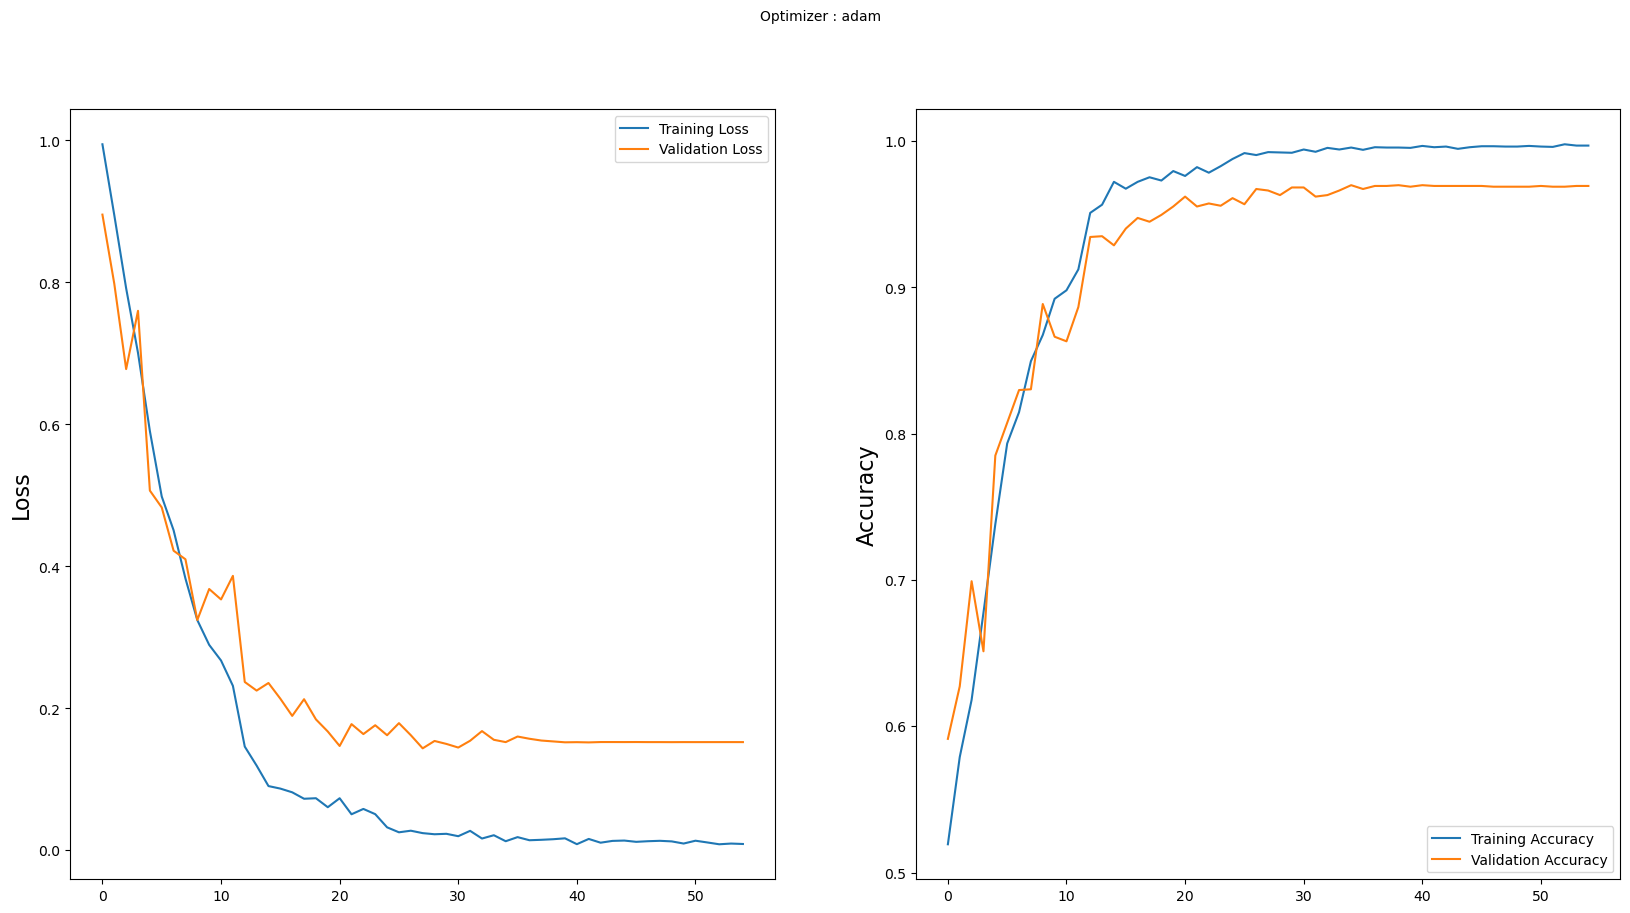

In [22]:
import matplotlib.pyplot as plt

x=hist15
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# NASNetMobile

In [23]:
from tensorflow.keras.applications import NASNetMobile

In [24]:
base = NASNetMobile(include_top=False, weights='imagenet', input_shape=(128,128,3))
x = base.output
x = GlobalAveragePooling2D()(x)
head = Dense(4, activation='softmax')(x)
model10 = Model(inputs=base.input, outputs=head)
model10.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
model10.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv1 (Conv2D)            (None, 63, 63, 32)   864         ['input_1[0][0]']                
                                                                                                  
 stem_bn1 (BatchNormalization)  (None, 63, 63, 32)   128         ['stem_conv1[0][0]']             
                                                                                                  
 activation (Activation)        (None, 63, 63, 32)   0           ['stem_bn1[0][0]']           

 right2_stem_1 (BatchNormalizat                                  t2_stem_1[0][0]']                
 ion)                                                                                             
                                                                                                  
 separable_conv_1_reduction_rig  (None, 32, 32, 11)  1152        ['separable_conv_1_pad_reduction_
 ht3_stem_1 (SeparableConv2D)                                    right3_stem_1[0][0]']            
                                                                                                  
 separable_conv_1_reduction_lef  (None, 32, 32, 11)  220         ['activation_9[0][0]']           
 t4_stem_1 (SeparableConv2D)                                                                      
                                                                                                  
 activation_6 (Activation)      (None, 32, 32, 11)   0           ['separable_conv_1_bn_reduction_r
          

                                                                                                  
 reduction_concat_stem_1 (Conca  (None, 32, 32, 44)  0           ['reduction_add_2_stem_1[0][0]', 
 tenate)                                                          'reduction_add3_stem_1[0][0]',  
                                                                  'add[0][0]',                    
                                                                  'reduction_add4_stem_1[0][0]']  
                                                                                                  
 adjust_avg_pool_1_stem_2 (Aver  (None, 32, 32, 32)  0           ['adjust_relu_1_stem_2[0][0]']   
 agePooling2D)                                                                                    
                                                                                                  
 adjust_avg_pool_2_stem_2 (Aver  (None, 32, 32, 32)  0           ['cropping2d[0][0]']             
 agePoolin

 reduction_add_1_stem_2 (Add)   (None, 16, 16, 22)   0           ['separable_conv_2_bn_reduction_l
                                                                 eft1_stem_2[0][0]',              
                                                                  'separable_conv_2_bn_reduction_r
                                                                 ight1_stem_2[0][0]']             
                                                                                                  
 separable_conv_1_reduction_rig  (None, 16, 16, 22)  1562        ['separable_conv_1_pad_reduction_
 ht2_stem_2 (SeparableConv2D)                                    right2_stem_2[0][0]']            
                                                                                                  
 separable_conv_1_pad_reduction  (None, 35, 35, 22)  0           ['activation_18[0][0]']          
 _right3_stem_2 (ZeroPadding2D)                                                                   
          

 D)                                                                                               
                                                                                                  
 reduction_add3_stem_2 (Add)    (None, 16, 16, 22)   0           ['reduction_left3_stem_2[0][0]', 
                                                                  'separable_conv_2_bn_reduction_r
                                                                 ight3_stem_2[0][0]']             
                                                                                                  
 add_1 (Add)                    (None, 16, 16, 22)   0           ['reduction_add_2_stem_2[0][0]', 
                                                                  'reduction_left4_stem_2[0][0]'] 
                                                                                                  
 reduction_add4_stem_2 (Add)    (None, 16, 16, 22)   0           ['separable_conv_2_bn_reduction_l
          

...

 separable_conv_1_normal_right2  (None, 4, 4, 176)   32560       ['activation_159[0][0]']         
 _10 (SeparableConv2D)                                                                            
                                                                                                  
 separable_conv_1_normal_left5_  (None, 4, 4, 176)   32560       ['activation_161[0][0]']         
 10 (SeparableConv2D)                                                                             
                                                                                                  
 separable_conv_1_bn_normal_lef  (None, 4, 4, 176)   704         ['separable_conv_1_normal_left1_1
 t1_10 (BatchNormalization)                                      0[0][0]']                        
                                                                                                  
 separable_conv_1_bn_normal_rig  (None, 4, 4, 176)   704         ['separable_conv_1_normal_right1_
 ht1_10 (B

                                                                 t2_10[0][0]']                    
                                                                                                  
 normal_add_3_10 (Add)          (None, 4, 4, 176)    0           ['normal_left3_10[0][0]',        
                                                                  'adjust_bn_10[0][0]']           
                                                                                                  
 normal_add_4_10 (Add)          (None, 4, 4, 176)    0           ['normal_left4_10[0][0]',        
                                                                  'normal_right4_10[0][0]']       
                                                                                                  
 normal_add_5_10 (Add)          (None, 4, 4, 176)    0           ['separable_conv_2_bn_normal_left
                                                                 5_10[0][0]',                     
          

 activation_172 (Activation)    (None, 4, 4, 176)    0           ['separable_conv_1_bn_normal_righ
                                                                 t2_11[0][0]']                    
                                                                                                  
 activation_174 (Activation)    (None, 4, 4, 176)    0           ['separable_conv_1_bn_normal_left
                                                                 5_11[0][0]']                     
                                                                                                  
 separable_conv_2_normal_left1_  (None, 4, 4, 176)   35376       ['activation_166[0][0]']         
 11 (SeparableConv2D)                                                                             
                                                                                                  
 separable_conv_2_normal_right1  (None, 4, 4, 176)   32560       ['activation_168[0][0]']         
 _11 (Sepa

                                                                                                  
 normal_bn_1_12 (BatchNormaliza  (None, 4, 4, 176)   704         ['normal_conv_1_12[0][0]']       
 tion)                                                                                            
                                                                                                  
 activation_177 (Activation)    (None, 4, 4, 176)    0           ['normal_bn_1_12[0][0]']         
                                                                                                  
 activation_179 (Activation)    (None, 4, 4, 176)    0           ['adjust_bn_12[0][0]']           
                                                                                                  
 activation_181 (Activation)    (None, 4, 4, 176)    0           ['adjust_bn_12[0][0]']           
                                                                                                  
 activatio

 separable_conv_2_bn_normal_rig  (None, 4, 4, 176)   704         ['separable_conv_2_normal_right2_
 ht2_12 (BatchNormalization)                                     12[0][0]']                       
                                                                                                  
 normal_left3_12 (AveragePoolin  (None, 4, 4, 176)   0           ['normal_bn_1_12[0][0]']         
 g2D)                                                                                             
                                                                                                  
 normal_left4_12 (AveragePoolin  (None, 4, 4, 176)   0           ['adjust_bn_12[0][0]']           
 g2D)                                                                                             
                                                                                                  
 normal_right4_12 (AveragePooli  (None, 4, 4, 176)   0           ['adjust_bn_12[0][0]']           
 ng2D)    

In [25]:
hist16 = model10.fit(train_set, validation_data=test_set, epochs=100, steps_per_epoch=len(train_set), validation_steps=len(test_set),callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 232s 95ms/step - loss: 1.0108 - accuracy: 0.4925 - f1_m: 0.3917 - precision_m: 0.5292 - recall_m: 0.3230 - val_loss: 0.9679 - val_accuracy: 0.5341 - val_f1_m: 0.4313 - val_precision_m: 0.5343 - val_recall_m: 0.3798 - lr: 0.0100
Epoch 2/100
2240/2240 [==============================] - 211s 94ms/step - loss: 0.9052 - accuracy: 0.5771 - f1_m: 0.4634 - precision_m: 0.5955 - recall_m: 0.3973 - val_loss: 0.9107 - val_accuracy: 0.5919 - val_f1_m: 0.4337 - val_precision_m: 0.5499 - val_recall_m: 0.3757 - lr: 0.0100
Epoch 3/100
2240/2240 [==============================] - 212s 95ms/step - loss: 0.8171 - accuracy: 0.6280 - f1_m: 0.5618 - precision_m: 0.6603 - recall_m: 0.5125 - val_loss: 0.8215 - val_accuracy: 0.6309 - val_f1_m: 0.5342 - val_precision_m: 0.6368 - val_recall_m: 0.4828 - lr: 0.0100
Epoch 4/100
2240/2240 [==============================] - 213s 95ms/step - loss: 0.7344 - accuracy: 0.6845 - f1_m: 0.6335 - precision_m: 0.7129 - 

Epoch 49: early stopping


In [50]:
dl_acc = hist16.history["val_accuracy"][48]
dl_prec = hist16.history["val_precision_m"][48]
dl_rec = hist16.history["val_recall_m"][48]
dl_f1 = hist16.history["val_f1_m"][48]

storeResults('NASNetMobile',dl_acc,dl_prec,dl_rec,dl_f1)

In [26]:
model10.save('nasnet.h5')

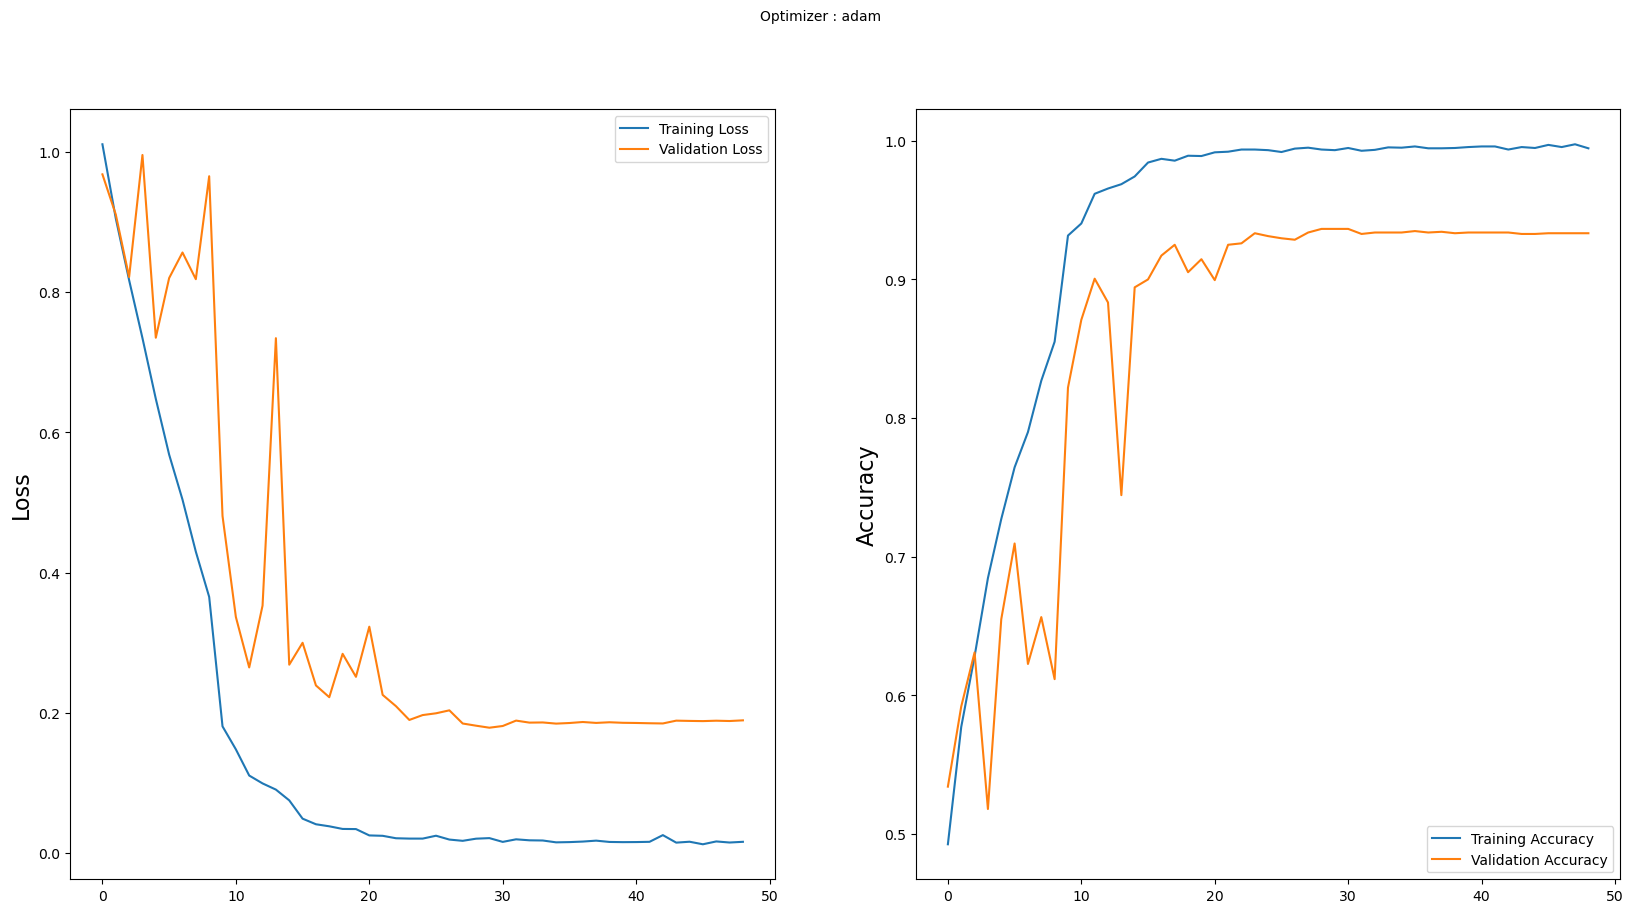

In [27]:
import matplotlib.pyplot as plt

x=hist16
plt.figure(figsize=(20,10))
plt.subplot(1, 2, 1)
plt.suptitle('Optimizer : adam', fontsize=10)
plt.ylabel('Loss', fontsize=16)
plt.plot(x.history['loss'], label='Training Loss')
plt.plot(x.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize=16)
plt.plot(x.history['accuracy'], label='Training Accuracy')
plt.plot(x.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

# Extension

In [28]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Average
import efficientnet.keras

In [29]:
def ensemble():

    model_1 = load_model('cnn1.h5', compile=False)
    model_1 = Model(inputs = model_1.inputs, outputs = model_1.outputs, name = 'CNN-Adam')

    model_2 = load_model('cnn2.h5', compile=False)
    model_2 = Model(inputs = model_2.inputs, outputs = model_2.outputs, name = 'CNN-SGD')
    
    model_3 = load_model('cnn3.h5', compile=False)
    model_3 = Model(inputs = model_3.inputs, outputs = model_3.outputs, name = 'CNN-Nadam')
    
    model_4 = load_model('nasnet.h5', compile=False)
    model_4 = Model(inputs = model_4.inputs, outputs = model_4.outputs, name = 'NASNet')
    
    models = [model_1, model_2,model_3, model_4]


    models_input = Input(shape =(128,128,3))
    models_output = [model(models_input) for model in models]
    
    ensemble_output = Average()(models_output)

    simple_average = Model(inputs = models_input, outputs = ensemble_output, name = 'IVX16')

    return simple_average

In [30]:
ext = ensemble()
ext.compile(optimizer='sgd', 
              loss = 'categorical_crossentropy', 
              metrics=["accuracy",f1_m,precision_m, recall_m])
ext.summary()

Model: "IVX16"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 CNN-Adam (Functional)          (None, 4)            11122264    ['input_2[0][0]']                
                                                                                                  
 CNN-SGD (Functional)           (None, 4)            11122264    ['input_2[0][0]']                
                                                                                                  
 CNN-Nadam (Functional)         (None, 4)            11122264    ['input_2[0][0]']            

In [31]:
history1 = ext.fit(
    train_set,
    epochs=100,
    validation_data=test_set,callbacks=[learning_rate_reduction, early_stop])

Epoch 1/100
2240/2240 [==============================] - 239s 99ms/step - loss: 0.0107 - accuracy: 0.9998 - f1_m: 0.9998 - precision_m: 0.9998 - recall_m: 0.9998 - val_loss: 0.0614 - val_accuracy: 0.9906 - val_f1_m: 0.9899 - val_precision_m: 0.9927 - val_recall_m: 0.9886 - lr: 0.0100
Epoch 2/100
2240/2240 [==============================] - 217s 97ms/step - loss: 0.0095 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_m: 1.0000 - val_loss: 0.0779 - val_accuracy: 0.9859 - val_f1_m: 0.9861 - val_precision_m: 0.9886 - val_recall_m: 0.9849 - lr: 0.0100
Epoch 3/100
2240/2240 [==============================] - 216s 97ms/step - loss: 0.0114 - accuracy: 0.9996 - f1_m: 0.9996 - precision_m: 0.9996 - recall_m: 0.9996 - val_loss: 0.0529 - val_accuracy: 0.9896 - val_f1_m: 0.9884 - val_precision_m: 0.9912 - val_recall_m: 0.9870 - lr: 0.0100
Epoch 4/100
2240/2240 [==============================] - ETA: 0s - loss: 0.0090 - accuracy: 1.0000 - f1_m: 1.0000 - precision_m: 1.0000 - recall_

Epoch 25/100
2240/2240 [==============================] - 217s 97ms/step - loss: 0.0051 - accuracy: 0.9998 - f1_m: 0.9998 - precision_m: 0.9998 - recall_m: 0.9998 - val_loss: 0.0488 - val_accuracy: 0.9917 - val_f1_m: 0.9912 - val_precision_m: 0.9932 - val_recall_m: 0.9901 - lr: 2.1870e-06
Epoch 26/100
2240/2240 [==============================] - 236s 105ms/step - loss: 0.0064 - accuracy: 0.9996 - f1_m: 0.9996 - precision_m: 0.9996 - recall_m: 0.9996 - val_loss: 0.0486 - val_accuracy: 0.9917 - val_f1_m: 0.9912 - val_precision_m: 0.9932 - val_recall_m: 0.9901 - lr: 2.1870e-06
Epoch 26: early stopping


In [51]:
dl_acc = history1.history["val_accuracy"][25]
dl_prec = history1.history["val_precision_m"][25]
dl_rec = history1.history["val_recall_m"][25]
dl_f1 = history1.history["val_f1_m"][25]

storeResults('Extension',dl_acc,dl_prec,dl_rec,dl_f1)

# Comparison

In [52]:
#creating dataframe
import pandas as pd
result = pd.DataFrame({ 'ML Model' : ML_Model,
                        'Accuracy' : accuracy,
                        'Precision': precision,
                        'Recall'   : recall,
                        'F1-Score': f1score,
                        
                      })

In [53]:
result

,ML Model,Accuracy,Precision,Recall,F1-Score
0,InceptionV3,0.527,0.538,0.432,0.467
1,Xception,0.992,0.992,0.992,0.992
2,ResNet50,0.505,0.444,0.300,0.348
3,ResNet152,0.585,0.595,0.473,0.514
4,ResNet101,0.579,0.497,0.312,0.373
5,ResNet008/V2,0.513,0.374,0.238,0.284
6,InceptionResNetV2,0.554,0.530,0.392,0.438
7,VGG19,0.500,0.500,0.500,0.500
8,MobileNetV2,0.753,0.770,0.736,0.747
9,DenseNet121,0.549,0.551,0.476,0.501


# Modelling

In [54]:
ext.save('extension.h5')

# Graph

In [55]:
classifier = ML_Model
y_pos = np.arange(len(classifier))

# Accuracy

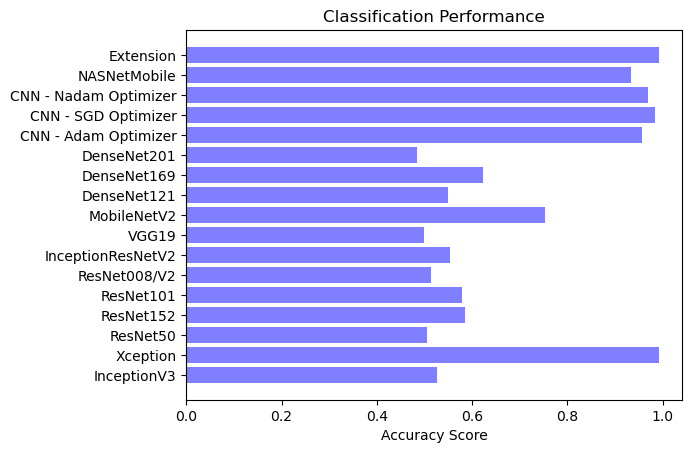

In [56]:
import matplotlib.pyplot as plt2
plt2.barh(y_pos, accuracy, align='center', alpha=0.5,color='blue')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Accuracy Score')
plt2.title('Classification Performance')
plt2.show()

# Precision

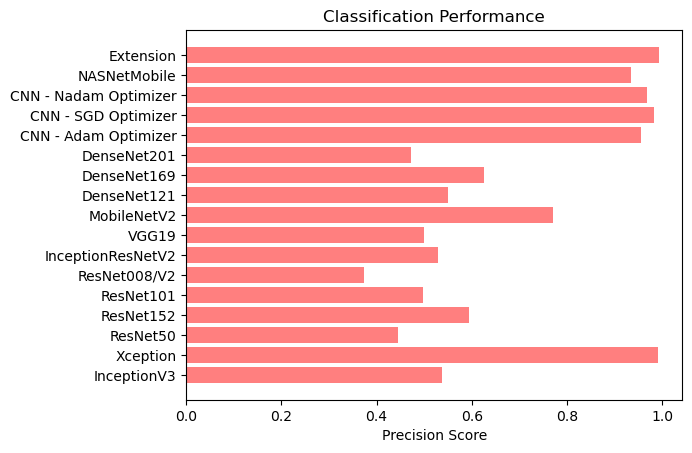

In [57]:
plt2.barh(y_pos, precision, align='center', alpha=0.5,color='red')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Precision Score')
plt2.title('Classification Performance')
plt2.show()

# Recall

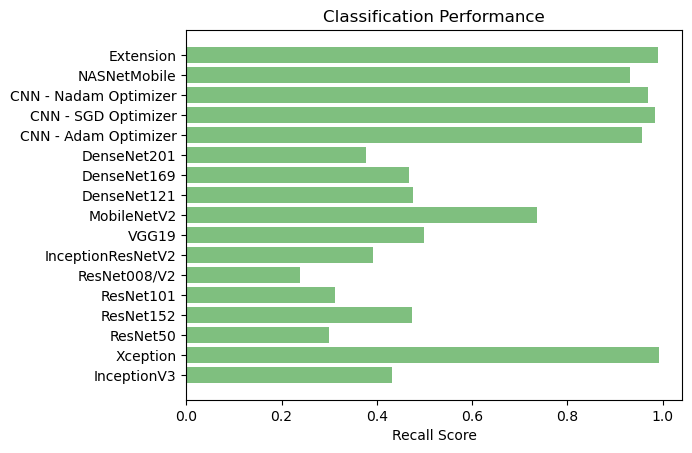

In [58]:
plt2.barh(y_pos, recall, align='center', alpha=0.5,color='green')
plt2.yticks(y_pos, classifier)
plt2.xlabel('Recall Score')
plt2.title('Classification Performance')
plt2.show()

# F1 Score

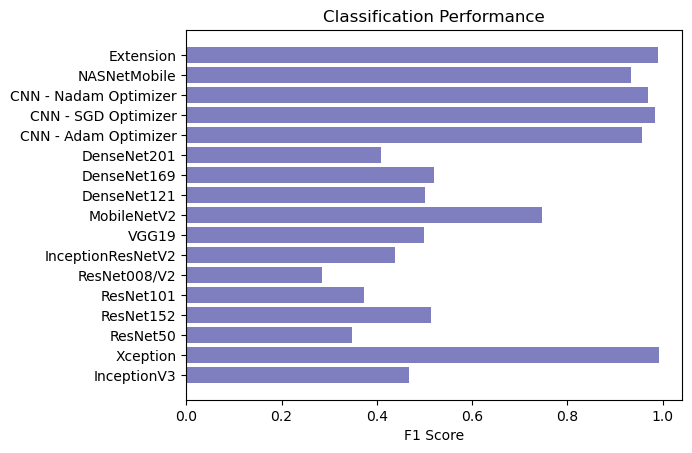

In [59]:
plt2.barh(y_pos, f1score, align='center', alpha=0.5,color='navy')
plt2.yticks(y_pos, classifier)
plt2.xlabel('F1 Score')
plt2.title('Classification Performance')
plt2.show()